In [1]:
!pip -q install pennylane gymnasium scipy pandas matplotlib scikit-learn

In [2]:
import os
import time
import json
import random
import warnings
from collections import deque
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim

import pennylane as qml

from scipy.stats import friedmanchisquare, wilcoxon

warnings.filterwarnings("ignore")

RESULT_DIR = "sepsis_asc_results"
FIG_DIR = os.path.join(RESULT_DIR, "figures")
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

DEVICE = torch.device("cpu")

print("Torch:", torch.__version__)
print("PennyLane:", qml.__version__)
print("Device:", DEVICE)

Torch: 2.10.0+cpu
PennyLane: 0.44.0
Device: cpu


In [3]:
EXPERIMENT_MODE = "pilot"   # "pilot" veya "final"

if EXPERIMENT_MODE == "pilot":
    SEEDS = [11, 22, 33]
    EPISODES = 200
    EVAL_EPISODES_PER_PROFILE = 10
elif EXPERIMENT_MODE == "final":
    SEEDS = list(range(1, 31))
    EPISODES = 400
    EVAL_EPISODES_PER_PROFILE = 20
else:
    raise ValueError("EXPERIMENT_MODE 'pilot' veya 'final' olmalı.")

BATCH_SIZE = 32
GAMMA = 0.95
LR = 1e-3
MEMORY_SIZE = 2000
EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.99
TARGET_UPDATE_FREQ = 10

HORIZON = 24
DEFAULT_NOISE_STD = 0.02
INIT_JITTER = 0.01

ALPHA_GRID = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

PATIENT_PROFILES = {
    "mild_risk":      np.array([0.55, 0.55, 0.35, 0.45], dtype=np.float32),
    "moderate_risk":  np.array([0.70, 0.40, 0.50, 0.60], dtype=np.float32),
    "high_risk":      np.array([0.85, 0.30, 0.70, 0.75], dtype=np.float32),
    "shock_like":     np.array([0.90, 0.20, 0.85, 0.85], dtype=np.float32),
    "recovering":     np.array([0.60, 0.65, 0.40, 0.50], dtype=np.float32),
}

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

print("Mode:", EXPERIMENT_MODE)
print("Seeds:", SEEDS)
print("Episodes:", EPISODES)
print("Profiles:", list(PATIENT_PROFILES.keys()))

Mode: pilot
Seeds: [11, 22, 33]
Episodes: 200
Profiles: ['mild_risk', 'moderate_risk', 'high_risk', 'shock_like', 'recovering']


In [4]:
class SepsisTitrationEnv(gym.Env):
    """
    Controlled in-silico sepsis vasopressor titration environment.
    State: [HR, MAP, Lactate, Infection], normalized to [0, 1].
    Actions: 0 = decrease dose, 1 = maintain dose, 2 = increase dose.
    """

    def __init__(
        self,
        profiles=None,
        profile_mode="random",
        default_profile="moderate_risk",
        horizon=24,
        noise_std=0.02,
        init_jitter=0.01,
        reward_mode="full",
        seed=None,
    ):
        super().__init__()

        self.profiles = profiles if profiles is not None else PATIENT_PROFILES
        self.profile_names = list(self.profiles.keys())
        self.profile_mode = profile_mode
        self.default_profile = default_profile

        self.horizon = horizon
        self.noise_std = noise_std
        self.init_jitter = init_jitter
        self.reward_mode = reward_mode

        self.action_space = spaces.Discrete(3)
        self.observation_space = spaces.Box(low=0, high=1, shape=(4,), dtype=np.float32)

        self.rng = np.random.default_rng(seed)

        self.state = None
        self.steps_left = None
        self.last_action = 1
        self.profile_name = None

    def reset(self, seed=None, options=None, profile=None):
        super().reset(seed=seed)

        if seed is not None:
            self.rng = np.random.default_rng(seed)

        if profile is None:
            if self.profile_mode == "random":
                profile = self.rng.choice(self.profile_names)
            else:
                profile = self.default_profile

        self.profile_name = profile
        base_state = self.profiles[profile].astype(np.float32).copy()

        if self.init_jitter > 0:
            base_state = base_state + self.rng.normal(0, self.init_jitter, size=4)

        self.state = np.clip(base_state, 0, 1).astype(np.float32)
        self.steps_left = self.horizon
        self.last_action = 1

        return self.state.copy(), {"profile": self.profile_name}

    def _compute_reward(self, next_state, action, previous_action):
        hr, map_val, lactate, infection = next_state

        reward = 0.0

        if 0.60 <= map_val <= 0.80:
            reward += 1.0
        elif map_val < 0.30:
            reward -= 5.0
        elif map_val > 0.90:
            reward -= 2.0
        else:
            reward -= 0.1

        if self.reward_mode == "map_only":
            return reward

        if self.reward_mode != "no_switching":
            if action != previous_action:
                reward -= 0.05

        if self.reward_mode != "no_lactate":
            if lactate > 0.80:
                reward -= 1.0

        return reward

    def step(self, action):
        action = int(action)

        hr, map_val, lactate, infection = self.state
        previous_action = self.last_action

        baseline_drift = 0.02

        if action == 0:
            # Decrease vasopressor
            map_val -= 0.10
            hr += 0.05
            lactate += 0.01

        elif action == 1:
            # Maintain vasopressor
            map_val -= 0.02
            infection += baseline_drift

        elif action == 2:
            # Increase vasopressor
            map_val += 0.10
            hr += 0.02
            lactate -= 0.05
            infection -= 0.005

        noise = self.rng.normal(0, self.noise_std, size=4)
        next_state = np.array([hr, map_val, lactate, infection], dtype=np.float32) + noise
        next_state = np.clip(next_state, 0, 1).astype(np.float32)

        reward = self._compute_reward(next_state, action, previous_action)

        self.steps_left -= 1

        terminal_bad = bool(next_state[1] < 0.10)
        time_limit = bool(self.steps_left <= 0)

        if terminal_bad and self.reward_mode != "no_terminal":
            reward = -10.0
            terminated = True
        else:
            terminated = time_limit

        self.state = next_state
        self.last_action = action

        info = {
            "profile": self.profile_name,
            "map_target": float(0.60 <= next_state[1] <= 0.80),
            "hypotension": float(next_state[1] < 0.30),
            "severe_hypotension": float(next_state[1] < 0.10),
            "lactate_high": float(next_state[2] > 0.80),
            "action_switch": float(action != previous_action),
            "terminal_bad": float(terminal_bad),
            "action": action,
        }

        return next_state.copy(), float(reward), terminated, False, info


# quick test
test_env = SepsisTitrationEnv(seed=42)
s, info = test_env.reset()
print("Initial state:", s)
print("Info:", info)

for _ in range(3):
    ns, r, done, _, info = test_env.step(test_env.action_space.sample())
    print("Next:", ns, "Reward:", r, "Done:", done, "Info:", info)

Initial state: [0.5396002  0.55750453 0.35940564 0.43048963]
Info: {'profile': np.str_('mild_risk')}
Next: [0.5135566  0.54006135 0.35308078 0.45015362] Reward: -0.1 Done: False Info: {'profile': np.str_('mild_risk'), 'map_target': 0.0, 'hypotension': 0.0, 'severe_hypotension': 0.0, 'lactate_high': 0.0, 'action_switch': 0.0, 'terminal_bad': 0.0, 'action': 1}
Next: [0.54649574 0.45764932 0.3786366  0.45147422] Reward: -0.15000000000000002 Done: False Info: {'profile': np.str_('mild_risk'), 'map_target': 0.0, 'hypotension': 0.0, 'severe_hypotension': 0.0, 'lactate_high': 0.0, 'action_switch': 1.0, 'terminal_bad': 0.0, 'action': 0}
Next: [0.5890405  0.5669995  0.31145075 0.45384923] Reward: -0.15000000000000002 Done: False Info: {'profile': np.str_('mild_risk'), 'map_target': 0.0, 'hypotension': 0.0, 'severe_hypotension': 0.0, 'lactate_high': 0.0, 'action_switch': 1.0, 'terminal_bad': 0.0, 'action': 2}


In [5]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class ClassicalQNet(nn.Module):
    def __init__(self, hidden_sizes=(64, 64), state_dim=4, action_dim=3):
        super().__init__()
        layers = []
        prev = state_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            prev = h

        layers.append(nn.Linear(prev, action_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.float())


def make_quantum_torch_layer(n_qubits=4, n_layers=3):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        for i in range(n_qubits):
            qml.RY(inputs[i] * np.pi, wires=i)

        for l in range(n_layers):
            for i in range(n_qubits):
                qml.Rot(
                    weights[l, i, 0],
                    weights[l, i, 1],
                    weights[l, i, 2],
                    wires=i
                )

            for i in range(n_qubits):
                qml.CNOT(wires=[i, (i + 1) % n_qubits])

        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shapes = {"weights": (n_layers, n_qubits, 3)}
    return qml.qnn.TorchLayer(circuit, weight_shapes)


class BatchedQuantumLayer(nn.Module):
    def __init__(self, n_qubits=4, n_layers=3):
        super().__init__()
        self.qlayer = make_quantum_torch_layer(n_qubits=n_qubits, n_layers=n_layers)

    def forward(self, x):
        if x.dim() == 1:
            return self.qlayer(x).float()

        outputs = []
        for row in x:
            outputs.append(self.qlayer(row).float())

        return torch.stack(outputs, dim=0)


class VQCQNet(nn.Module):
    def __init__(self, n_qubits=4, n_layers=3, state_dim=4, action_dim=3):
        super().__init__()

        self.encoder = nn.Linear(state_dim, n_qubits)
        self.quantum = BatchedQuantumLayer(n_qubits=n_qubits, n_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(n_qubits, 16),
            nn.ReLU(),
            nn.Linear(16, action_dim)
        )

    def forward(self, x):
        x = torch.tanh(self.encoder(x.float()))
        q = self.quantum(x)
        return self.head(q.float())


# Model parameter check
models_to_check = {
    "Small-DQN": ClassicalQNet(hidden_sizes=(16, 8)),
    "Standard-DQN": ClassicalQNet(hidden_sizes=(64, 64)),
    "VQC-DQN": VQCQNet(n_qubits=4, n_layers=3),
}

for name, model in models_to_check.items():
    print(name, "trainable params:", count_trainable_params(model))

Small-DQN trainable params: 243
Standard-DQN trainable params: 4675
VQC-DQN trainable params: 187


In [6]:
class ReplayBuffer:
    def __init__(self, capacity=2000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)

        states = np.array([b[0] for b in batch], dtype=np.float32)
        actions = np.array([b[1] for b in batch], dtype=np.int64)
        rewards = np.array([b[2] for b in batch], dtype=np.float32)
        next_states = np.array([b[3] for b in batch], dtype=np.float32)
        dones = np.array([b[4] for b in batch], dtype=np.float32)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    def __init__(
        self,
        model,
        action_dim=3,
        lr=1e-3,
        gamma=0.95,
        batch_size=32,
        memory_size=2000,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.99,
        device=DEVICE,
    ):
        self.model = model.to(device)
        self.target_model = type(model)() if False else None

        # safer deep copy for arbitrary model class
        import copy
        self.target_model = copy.deepcopy(self.model).to(device)
        self.target_model.load_state_dict(self.model.state_dict())
        self.target_model.eval()

        self.action_dim = action_dim
        self.gamma = gamma
        self.batch_size = batch_size
        self.memory = ReplayBuffer(memory_size)

        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay

        self.device = device
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def q_values(self, state):
        self.model.eval()
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
            q = self.model(s).cpu().numpy()[0]
        self.model.train()
        return q

    def act(self, state, explore=True):
        if explore and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        q = self.q_values(state)
        return int(np.argmax(q))

    def remember(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return np.nan

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)

        states = torch.tensor(states, dtype=torch.float32, device=self.device)
        actions = torch.tensor(actions, dtype=torch.long, device=self.device).unsqueeze(1)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=self.device).unsqueeze(1)
        next_states = torch.tensor(next_states, dtype=torch.float32, device=self.device)
        dones = torch.tensor(dones, dtype=torch.float32, device=self.device).unsqueeze(1)

        self.model.train()

        current_q = self.model(states).gather(1, actions)

        with torch.no_grad():
            next_q = self.target_model(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + self.gamma * next_q * (1.0 - dones)

        loss = self.loss_fn(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        self.optimizer.step()

        return float(loss.item())

    def update_target(self):
        self.target_model.load_state_dict(self.model.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [7]:
def train_agent(model_name, model_factory, seed, env_kwargs, episodes=200):
    set_global_seed(seed)

    env = SepsisTitrationEnv(**env_kwargs, seed=seed)

    model = model_factory()
    agent = DQNAgent(
        model=model,
        lr=LR,
        gamma=GAMMA,
        batch_size=BATCH_SIZE,
        memory_size=MEMORY_SIZE,
        epsilon_start=EPSILON_START,
        epsilon_min=EPSILON_MIN,
        epsilon_decay=EPSILON_DECAY,
        device=DEVICE,
    )

    history = []

    start_time = time.time()

    for ep in range(episodes):
        state, info = env.reset()
        total_reward = 0.0
        losses = []
        done = False
        step_count = 0

        while not done:
            action = agent.act(state, explore=True)
            next_state, reward, done, _, info = env.step(action)

            agent.remember(state, action, reward, next_state, done)
            loss = agent.train_step()

            if not np.isnan(loss):
                losses.append(loss)

            state = next_state
            total_reward += reward
            step_count += 1

        agent.decay_epsilon()

        if ep % TARGET_UPDATE_FREQ == 0:
            agent.update_target()

        history.append({
            "model": model_name,
            "seed": seed,
            "episode": ep,
            "episode_reward": total_reward,
            "epsilon": agent.epsilon,
            "mean_loss": np.nanmean(losses) if len(losses) > 0 else np.nan,
            "steps": step_count,
        })

        if ep % 20 == 0 or ep == episodes - 1:
            print(
                f"{model_name} | seed={seed} | ep={ep:03d}/{episodes} | "
                f"reward={total_reward:.2f} | eps={agent.epsilon:.3f}"
            )

    elapsed = time.time() - start_time
    print(f"Finished {model_name}, seed={seed}, time={elapsed/60:.2f} min")

    return agent, pd.DataFrame(history)


def random_policy_fn(state):
    return random.randrange(3)


def rule_based_policy_fn(state):
    hr, map_val, lactate, infection = state

    if map_val < 0.55 or lactate > 0.75:
        return 2  # increase dose

    if map_val > 0.82:
        return 0  # decrease dose

    if hr > 0.90 and map_val > 0.70:
        return 0

    return 1  # maintain dose


def agent_policy_fn(agent):
    def policy(state):
        return agent.act(state, explore=False)
    return policy


def fusion_policy_fn(vqc_agent, classical_agent, alpha=0.8):
    def policy(state):
        q_vqc = vqc_agent.q_values(state)
        q_cls = classical_agent.q_values(state)
        q_fused = alpha * q_vqc + (1.0 - alpha) * q_cls
        return int(np.argmax(q_fused))
    return policy


def run_eval_episode(env, policy_fn, profile):
    state, info = env.reset(profile=profile)

    total_reward = 0.0
    done = False
    steps = 0

    metric_sums = {
        "map_target_ratio": 0.0,
        "hypotension_rate": 0.0,
        "severe_hypotension_rate": 0.0,
        "lactate_high_rate": 0.0,
        "action_switch_rate": 0.0,
        "terminal_bad": 0.0,
    }

    action_counts = {0: 0, 1: 0, 2: 0}

    while not done:
        action = int(policy_fn(state))
        next_state, reward, done, _, info = env.step(action)

        total_reward += reward
        steps += 1
        action_counts[action] += 1

        metric_sums["map_target_ratio"] += info["map_target"]
        metric_sums["hypotension_rate"] += info["hypotension"]
        metric_sums["severe_hypotension_rate"] += info["severe_hypotension"]
        metric_sums["lactate_high_rate"] += info["lactate_high"]
        metric_sums["action_switch_rate"] += info["action_switch"]
        metric_sums["terminal_bad"] = max(metric_sums["terminal_bad"], info["terminal_bad"])

        state = next_state

    row = {
        "profile": profile,
        "reward": total_reward,
        "steps": steps,
        "terminal_bad": metric_sums["terminal_bad"],
        "action_decrease_count": action_counts[0],
        "action_maintain_count": action_counts[1],
        "action_increase_count": action_counts[2],
    }

    for k, v in metric_sums.items():
        if k != "terminal_bad":
            row[k] = v / max(steps, 1)

    return row


def evaluate_policy(
    model_label,
    policy_fn,
    seed,
    env_kwargs,
    eval_episodes_per_profile=10,
    profiles=None,
):
    if profiles is None:
        profiles = list(PATIENT_PROFILES.keys())

    rows = []

    for profile in profiles:
        for rep in range(eval_episodes_per_profile):
            env_seed = 100000 + seed * 1000 + rep
            env = SepsisTitrationEnv(
                **env_kwargs,
                profile_mode="fixed",
                default_profile=profile,
                seed=env_seed,
            )

            row = run_eval_episode(env, policy_fn, profile)
            row["model"] = model_label
            row["seed"] = seed
            row["rep"] = rep
            rows.append(row)

    return pd.DataFrame(rows)

In [9]:
ENV_KWARGS = {
    "profiles": PATIENT_PROFILES,
    "profile_mode": "random",
    "default_profile": "moderate_risk",
    "horizon": HORIZON,
    "noise_std": DEFAULT_NOISE_STD,
    "init_jitter": INIT_JITTER,
    "reward_mode": "full",
}

all_histories = []
all_eval_results = []
trained_agents = {}

for seed in SEEDS:
    print("\n" + "=" * 80)
    print(f"SEED {seed}")
    print("=" * 80)

    # Non-learning baselines
    set_global_seed(seed);

    # Create a temporary copy of ENV_KWARGS for evaluation, removing 'profile_mode'
    # as evaluate_policy will explicitly set it to "fixed".
    _eval_env_kwargs = ENV_KWARGS.copy()
    _eval_env_kwargs.pop('profile_mode', None)
    _eval_env_kwargs.pop('default_profile', None)

    random_eval = evaluate_policy(
        "Random",
        random_policy_fn,
        seed,
        _eval_env_kwargs, # Use the modified kwargs
        eval_episodes_per_profile=EVAL_EPISODES_PER_PROFILE,
    )
    all_eval_results.append(random_eval)

    rule_eval = evaluate_policy(
        "RuleBased",
        rule_based_policy_fn,
        seed,
        _eval_env_kwargs, # Use the modified kwargs
        eval_episodes_per_profile=EVAL_EPISODES_PER_PROFILE,
    )
    all_eval_results.append(rule_eval)

    # Small DQN
    small_agent, small_hist = train_agent(
        "Small-DQN",
        lambda: ClassicalQNet(hidden_sizes=(16, 8)),
        seed,
        ENV_KWARGS,
        episodes=EPISODES,
    )
    all_histories.append(small_hist)

    small_eval = evaluate_policy(
        "Small-DQN",
        agent_policy_fn(small_agent),
        seed,
        _eval_env_kwargs, # Use the modified kwargs
        eval_episodes_per_profile=EVAL_EPISODES_PER_PROFILE,
    )
    all_eval_results.append(small_eval)

    # Standard DQN
    dqn_agent, dqn_hist = train_agent(
        "Standard-DQN",
        lambda: ClassicalQNet(hidden_sizes=(64, 64)),
        seed,
        ENV_KWARGS,
        episodes=EPISODES,
    )
    all_histories.append(dqn_hist)

    dqn_eval = evaluate_policy(
        "Standard-DQN",
        agent_policy_fn(dqn_agent),
        seed,
        _eval_env_kwargs, # Use the modified kwargs
        eval_episodes_per_profile=EVAL_EPISODES_PER_PROFILE,
    )
    all_eval_results.append(dqn_eval)

    # VQC-DQN
    vqc_agent, vqc_hist = train_agent(
        "VQC-DQN",
        lambda: VQCQNet(n_qubits=4, n_layers=3),
        seed,
        ENV_KWARGS,
        episodes=EPISODES,
    )
    all_histories.append(vqc_hist)

    vqc_eval = evaluate_policy(
        "VQC-DQN",
        agent_policy_fn(vqc_agent),
        seed,
        _eval_env_kwargs, # Use the modified kwargs
        eval_episodes_per_profile=EVAL_EPISODES_PER_PROFILE,
    )
    all_eval_results.append(vqc_eval)

    # Real fusion with actual trained Standard-DQN + VQC-DQN
    for alpha in ALPHA_GRID:
        label = f"Fusion-a{alpha:.1f}"
        fusion_eval = evaluate_policy(
            label,
            fusion_policy_fn(vqc_agent, dqn_agent, alpha=alpha),
            seed,
            _eval_env_kwargs, # Use the modified kwargs
            eval_episodes_per_profile=EVAL_EPISODES_PER_PROFILE,
        )
        all_eval_results.append(fusion_eval)

    trained_agents[seed] = {
        "Small-DQN": small_agent,
        "Standard-DQN": dqn_agent,
        "VQC-DQN": vqc_agent,
    }

hist_df = pd.concat(all_histories, ignore_index=True)
eval_df = pd.concat(all_eval_results, ignore_index=True)

hist_path = os.path.join(RESULT_DIR, "training_history.csv")
eval_path = os.path.join(RESULT_DIR, "evaluation_episode_metrics.csv")

hist_df.to_csv(hist_path, index=False)
eval_df.to_csv(eval_path, index=False)

print("Saved:", hist_path)
print("Saved:", eval_path)

display(eval_df.head())


SEED 11
Small-DQN | seed=11 | ep=000/200 | reward=-23.10 | eps=0.990
Small-DQN | seed=11 | ep=020/200 | reward=-26.65 | eps=0.810
Small-DQN | seed=11 | ep=040/200 | reward=7.85 | eps=0.662
Small-DQN | seed=11 | ep=060/200 | reward=-0.85 | eps=0.542
Small-DQN | seed=11 | ep=080/200 | reward=5.90 | eps=0.443
Small-DQN | seed=11 | ep=100/200 | reward=12.15 | eps=0.362
Small-DQN | seed=11 | ep=120/200 | reward=5.60 | eps=0.296
Small-DQN | seed=11 | ep=140/200 | reward=19.80 | eps=0.242
Small-DQN | seed=11 | ep=160/200 | reward=16.55 | eps=0.198
Small-DQN | seed=11 | ep=180/200 | reward=16.60 | eps=0.162
Small-DQN | seed=11 | ep=199/200 | reward=20.00 | eps=0.134
Finished Small-DQN, seed=11, time=0.27 min
Standard-DQN | seed=11 | ep=000/200 | reward=-23.10 | eps=0.990
Standard-DQN | seed=11 | ep=020/200 | reward=-17.95 | eps=0.810
Standard-DQN | seed=11 | ep=040/200 | reward=8.85 | eps=0.662
Standard-DQN | seed=11 | ep=060/200 | reward=-0.85 | eps=0.542
Standard-DQN | seed=11 | ep=080/200 

,profile,reward,steps,terminal_bad,action_decrease_count,action_maintain_count,action_increase_count,map_target_ratio,hypotension_rate,severe_hypotension_rate,lactate_high_rate,action_switch_rate,model,seed,rep
0,mild_risk,10.10,24,0.0,7,7,10,0.500000,0.000000,0.000000,0.0,0.583333,Random,11,0
1,mild_risk,-21.00,24,0.0,10,4,10,0.250000,0.208333,0.000000,0.0,0.583333,Random,11,1
2,mild_risk,-37.55,23,1.0,8,9,6,0.000000,0.260870,0.043478,0.0,0.782609,Random,11,2
3,mild_risk,-25.55,8,1.0,5,2,1,0.000000,0.500000,0.125000,0.0,0.375000,Random,11,3
4,mild_risk,-20.30,21,1.0,8,9,4,0.095238,0.142857,0.047619,0.0,0.666667,Random,11,4


In [16]:
summary = (
    eval_df
    .groupby("model")
    .agg(
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        reward_median=("reward", "median"),
        map_target_ratio=("map_target_ratio", "mean"),
        hypotension_rate=("hypotension_rate", "mean"),
        severe_hypotension_rate=("severe_hypotension_rate", "mean"),
        lactate_high_rate=("lactate_high_rate", "mean"),
        action_switch_rate=("action_switch_rate", "mean"),
        terminal_bad_rate=("terminal_bad", "mean"),
        mean_steps=("steps", "mean"),
    )
    .sort_values("reward_mean", ascending=False)
)

summary_path = os.path.join(RESULT_DIR, "summary_by_model.csv")
summary.to_csv(summary_path)

print("Saved:", summary_path)
display(summary)

Saved: sepsis_asc_results\summary_by_model.csv


,reward_mean,reward_std,reward_median,map_target_ratio,hypotension_rate,severe_hypotension_rate,lactate_high_rate,action_switch_rate,terminal_bad_rate,mean_steps
model,,,,,,,,,,
Fusion-a0.8,21.108000,2.767362,21.400,0.929722,0.004167,0.000000,0.003611,0.383333,0.0,24.000000
Fusion-a0.6,21.067333,2.739764,21.400,0.928333,0.004167,0.000000,0.003611,0.386667,0.0,24.000000
Fusion-a1.0,20.883000,3.046082,21.400,0.925000,0.004167,0.000000,0.003611,0.382500,0.0,24.000000
VQC-DQN,20.883000,3.046082,21.400,0.925000,0.004167,0.000000,0.003611,0.382500,0.0,24.000000
Fusion-a0.4,20.855333,2.698938,21.300,0.921111,0.004167,0.000000,0.003611,0.404444,0.0,24.000000
Fusion-a0.2,20.512667,2.780144,21.225,0.908889,0.004167,0.000000,0.003611,0.421111,0.0,24.000000
Fusion-a0.0,19.945000,2.987562,20.300,0.888333,0.004167,0.000000,0.003611,0.441944,0.0,24.000000
Standard-DQN,19.945000,2.987562,20.300,0.888333,0.004167,0.000000,0.003611,0.441944,0.0,24.000000
Small-DQN,17.181667,6.310486,19.900,0.783889,0.004167,0.000000,0.003611,0.446944,0.0,24.000000


In [17]:
alpha_rows = []

for model_name in eval_df["model"].unique():
    if model_name.startswith("Fusion-a"):
        alpha_value = float(model_name.split("a")[1])
        sub = eval_df[eval_df["model"] == model_name]
        alpha_rows.append({
            "alpha": alpha_value,
            "reward_mean": sub["reward"].mean(),
            "reward_std": sub["reward"].std(),
            "map_target_ratio": sub["map_target_ratio"].mean(),
            "hypotension_rate": sub["hypotension_rate"].mean(),
            "lactate_high_rate": sub["lactate_high_rate"].mean(),
            "action_switch_rate": sub["action_switch_rate"].mean(),
            "terminal_bad_rate": sub["terminal_bad"].mean(),
        })

alpha_df = pd.DataFrame(alpha_rows).sort_values("alpha")
alpha_path = os.path.join(RESULT_DIR, "alpha_sensitivity.csv")
alpha_df.to_csv(alpha_path, index=False)

print("Saved:", alpha_path)
display(alpha_df)

Saved: sepsis_asc_results\alpha_sensitivity.csv


,alpha,reward_mean,reward_std,map_target_ratio,hypotension_rate,lactate_high_rate,action_switch_rate,terminal_bad_rate
0,0.0,19.945000,2.987562,0.888333,0.004167,0.003611,0.441944,0.0
1,0.2,20.512667,2.780144,0.908889,0.004167,0.003611,0.421111,0.0
2,0.4,20.855333,2.698938,0.921111,0.004167,0.003611,0.404444,0.0
3,0.6,21.067333,2.739764,0.928333,0.004167,0.003611,0.386667,0.0
4,0.8,21.108000,2.767362,0.929722,0.004167,0.003611,0.383333,0.0
5,1.0,20.883000,3.046082,0.925000,0.004167,0.003611,0.382500,0.0


In [18]:
seed_model_reward = (
    eval_df
    .groupby(["seed", "model"])["reward"]
    .mean()
    .unstack()
)

display(seed_model_reward)

stat_models = [
    "Random",
    "RuleBased",
    "Small-DQN",
    "Standard-DQN",
    "VQC-DQN",
    "Fusion-a0.8",
]

available_models = [m for m in stat_models if m in seed_model_reward.columns]

if len(SEEDS) >= 3 and len(available_models) >= 3:
    arrays = [seed_model_reward[m].dropna().values for m in available_models]
    friedman_stat, friedman_p = friedmanchisquare(*arrays)

    print("Friedman test")
    print("Models:", available_models)
    print("Statistic:", friedman_stat)
    print("p-value:", friedman_p)

    pairwise_rows = []
    if "Fusion-a0.8" in seed_model_reward.columns:
        base = seed_model_reward["Fusion-a0.8"].values

        for m in available_models:
            if m == "Fusion-a0.8":
                continue

            comp = seed_model_reward[m].values

            try:
                w_stat, w_p = wilcoxon(base, comp)
            except ValueError:
                w_stat, w_p = np.nan, np.nan

            pairwise_rows.append({
                "comparison": f"Fusion-a0.8 vs {m}",
                "wilcoxon_stat": w_stat,
                "p_value": w_p,
                "fusion_mean": np.mean(base),
                "other_mean": np.mean(comp),
            })

    pairwise_df = pd.DataFrame(pairwise_rows)
    pairwise_path = os.path.join(RESULT_DIR, "pairwise_wilcoxon.csv")
    pairwise_df.to_csv(pairwise_path, index=False)

    display(pairwise_df)
else:
    print("Pilot mode: statistical testing is only preliminary. Use final mode for paper-level p-values.")

model,Fusion-a0.0,Fusion-a0.2,Fusion-a0.4,Fusion-a0.6,Fusion-a0.8,Fusion-a1.0,Random,RuleBased,Small-DQN,Standard-DQN,VQC-DQN
seed,,,,,,,,,,,
11,20.901,20.986,21.091,21.122,21.130,21.100,-24.004,7.142,20.180,20.901,21.100
22,19.460,20.362,20.771,21.107,21.144,21.211,-24.362,7.830,20.166,19.460,21.211
33,19.474,20.190,20.704,20.973,21.050,20.338,-26.736,7.739,11.199,19.474,20.338


Friedman test
Models: ['Random', 'RuleBased', 'Small-DQN', 'Standard-DQN', 'VQC-DQN', 'Fusion-a0.8']
Statistic: 14.23809523809524
p-value: 0.014165683684850317


,comparison,wilcoxon_stat,p_value,fusion_mean,other_mean
0,Fusion-a0.8 vs Random,0.0,0.25,21.108,-25.034000
1,Fusion-a0.8 vs RuleBased,0.0,0.25,21.108,7.570333
2,Fusion-a0.8 vs Small-DQN,0.0,0.25,21.108,17.181667
3,Fusion-a0.8 vs Standard-DQN,0.0,0.25,21.108,19.945000
4,Fusion-a0.8 vs VQC-DQN,2.0,0.75,21.108,20.883000


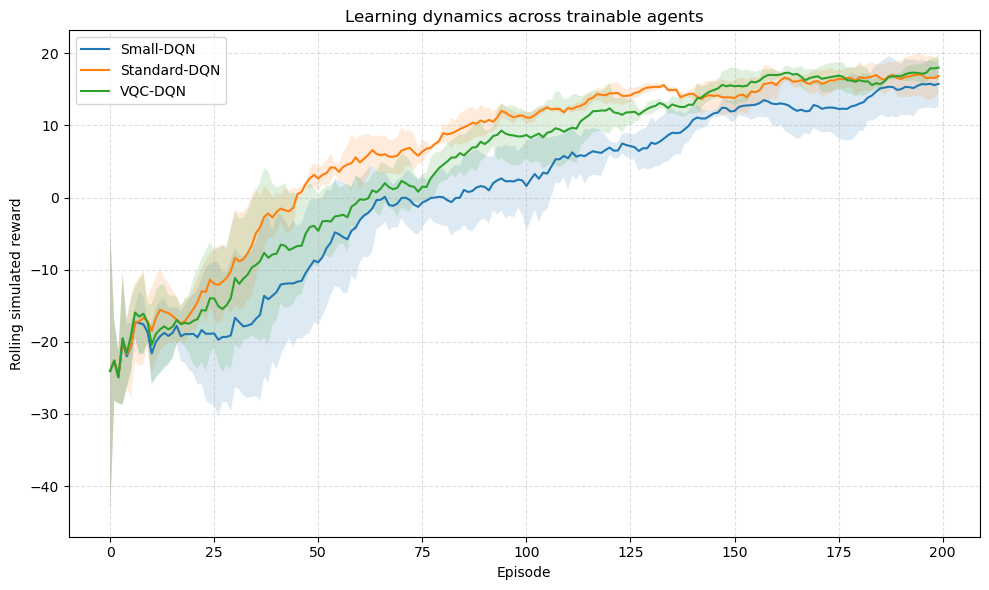

Saved: sepsis_asc_results\figures\fig_learning_curves.png


In [19]:
hist_plot = hist_df.copy()
hist_plot["rolling_reward"] = (
    hist_plot
    .groupby(["model", "seed"])["episode_reward"]
    .transform(lambda x: x.rolling(window=20, min_periods=1).mean())
)

curve_df = (
    hist_plot
    .groupby(["model", "episode"])
    .agg(
        mean_reward=("rolling_reward", "mean"),
        std_reward=("rolling_reward", "std")
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

for model_name, sub in curve_df.groupby("model"):
    plt.plot(sub["episode"], sub["mean_reward"], label=model_name)
    lower = sub["mean_reward"] - sub["std_reward"].fillna(0)
    upper = sub["mean_reward"] + sub["std_reward"].fillna(0)
    plt.fill_between(sub["episode"], lower, upper, alpha=0.15)

plt.xlabel("Episode")
plt.ylabel("Rolling simulated reward")
plt.title("Learning dynamics across trainable agents")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_learning_curves.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

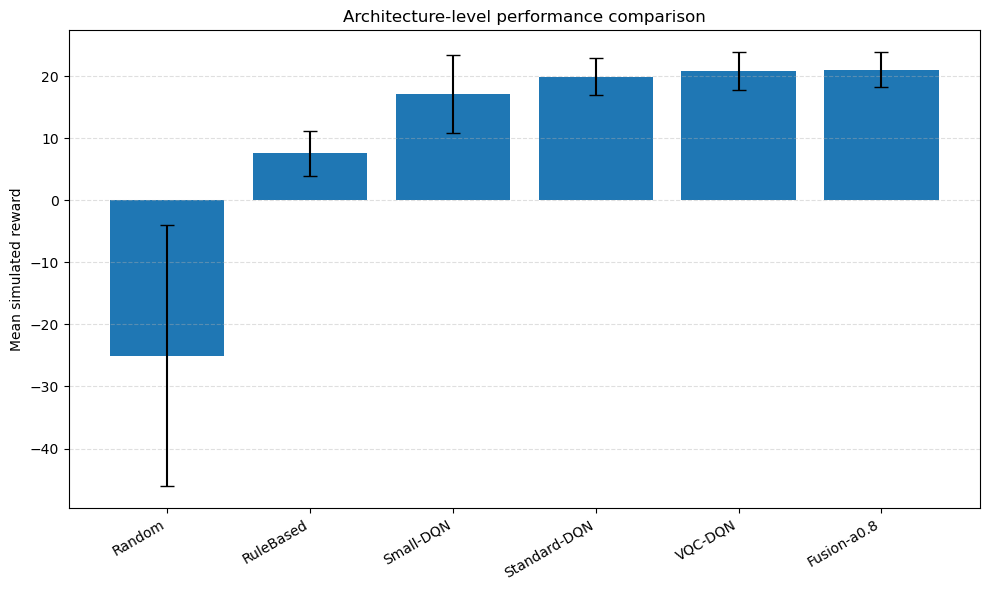

Saved: sepsis_asc_results\figures\fig_model_performance.png


In [20]:
preferred_order = [
    "Random",
    "RuleBased",
    "Small-DQN",
    "Standard-DQN",
    "VQC-DQN",
    "Fusion-a0.8",
]

plot_summary = summary.loc[[m for m in preferred_order if m in summary.index]].reset_index()

plt.figure(figsize=(10, 6))
plt.bar(
    plot_summary["model"],
    plot_summary["reward_mean"],
    yerr=plot_summary["reward_std"],
    capsize=5
)
plt.ylabel("Mean simulated reward")
plt.title("Architecture-level performance comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_model_performance.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

,model,map_target_ratio,hypotension_rate,lactate_high_rate,action_switch_rate,terminal_bad_rate
0,Random,0.111387,0.453916,0.110762,0.652201,0.6
1,RuleBased,0.415833,0.004167,0.003611,0.359167,0.0
2,Small-DQN,0.783889,0.004167,0.003611,0.446944,0.0
3,Standard-DQN,0.888333,0.004167,0.003611,0.441944,0.0
4,VQC-DQN,0.925000,0.004167,0.003611,0.382500,0.0
5,Fusion-a0.8,0.929722,0.004167,0.003611,0.383333,0.0


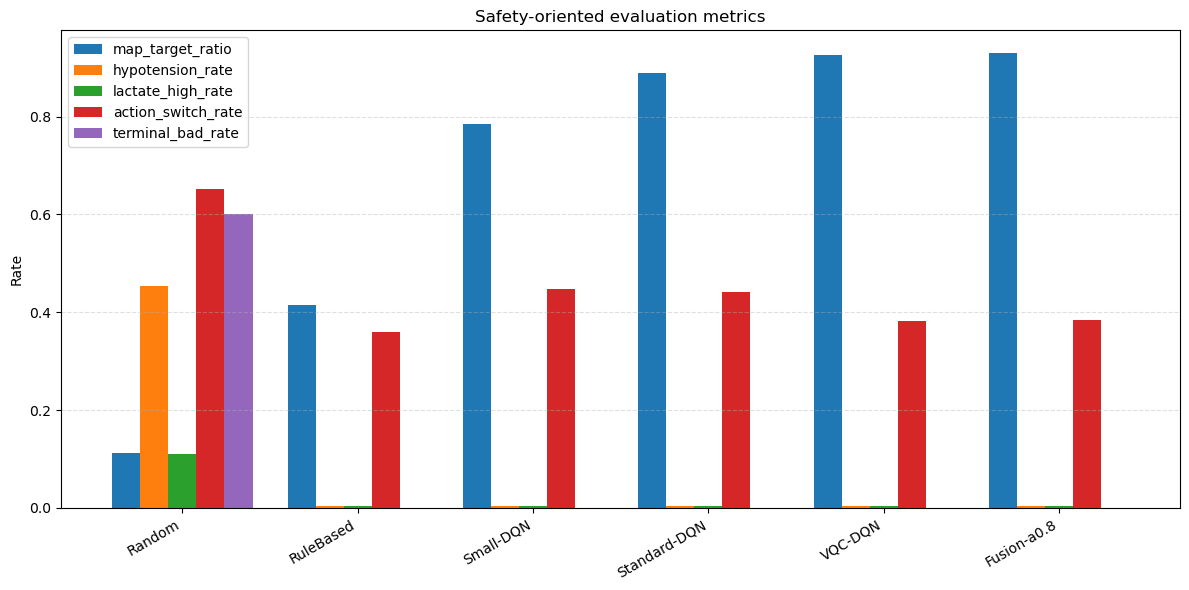

Saved: sepsis_asc_results\figures\fig_safety_metrics.png


In [21]:
safety_models = [m for m in preferred_order if m in summary.index]

safety_df = summary.loc[safety_models, [
    "map_target_ratio",
    "hypotension_rate",
    "lactate_high_rate",
    "action_switch_rate",
    "terminal_bad_rate",
]].reset_index()

display(safety_df)

x = np.arange(len(safety_df["model"]))
width = 0.16

plt.figure(figsize=(12, 6))

metric_cols = [
    "map_target_ratio",
    "hypotension_rate",
    "lactate_high_rate",
    "action_switch_rate",
    "terminal_bad_rate",
]

for i, metric in enumerate(metric_cols):
    plt.bar(x + i * width, safety_df[metric], width=width, label=metric)

plt.xticks(x + width * 2, safety_df["model"], rotation=30, ha="right")
plt.ylabel("Rate")
plt.title("Safety-oriented evaluation metrics")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_safety_metrics.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

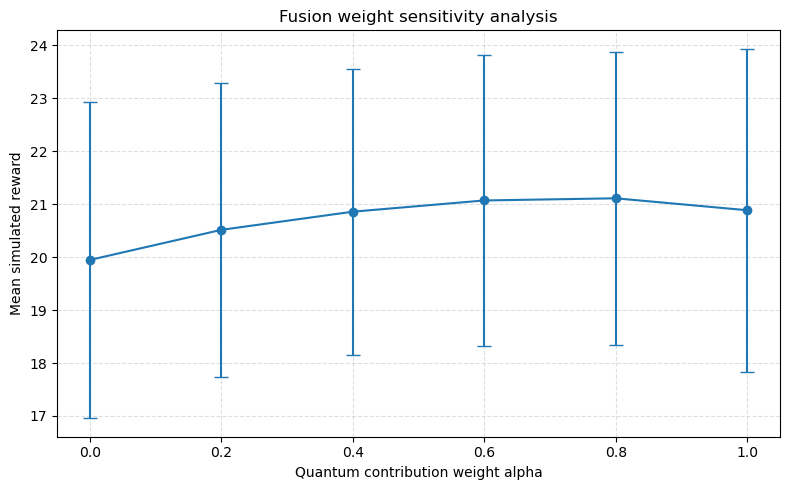

Saved: sepsis_asc_results\figures\fig_alpha_sensitivity.png


In [22]:
plt.figure(figsize=(8, 5))
plt.errorbar(
    alpha_df["alpha"],
    alpha_df["reward_mean"],
    yerr=alpha_df["reward_std"],
    marker="o",
    capsize=5
)
plt.xlabel("Quantum contribution weight alpha")
plt.ylabel("Mean simulated reward")
plt.title("Fusion weight sensitivity analysis")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_alpha_sensitivity.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [23]:
print("Generated files:")
for root, dirs, files in os.walk(RESULT_DIR):
    for f in files:
        print(os.path.join(root, f))

Generated files:
sepsis_asc_results\alpha_sensitivity.csv
sepsis_asc_results\evaluation_episode_metrics.csv
sepsis_asc_results\pairwise_wilcoxon.csv
sepsis_asc_results\summary_by_model.csv
sepsis_asc_results\summary_by_model_and_profile.csv
sepsis_asc_results\training_history.csv
sepsis_asc_results\figures\fig_alpha_sensitivity.png
sepsis_asc_results\figures\fig_learning_curves.png
sepsis_asc_results\figures\fig_model_performance.png
sepsis_asc_results\figures\fig_safety_metrics.png


,alpha,reward_mean,reward_std,reward_se,reward_ci95,n_seeds
0,0.0,19.945000,0.827950,0.478017,0.936913,3
1,0.2,20.512667,0.418843,0.241819,0.473965,3
2,0.4,20.855333,0.206824,0.119410,0.234044,3
3,0.6,21.067333,0.082039,0.047365,0.092835,3
4,0.8,21.108000,0.050715,0.029280,0.057389,3
5,1.0,20.883000,0.475236,0.274377,0.537780,3


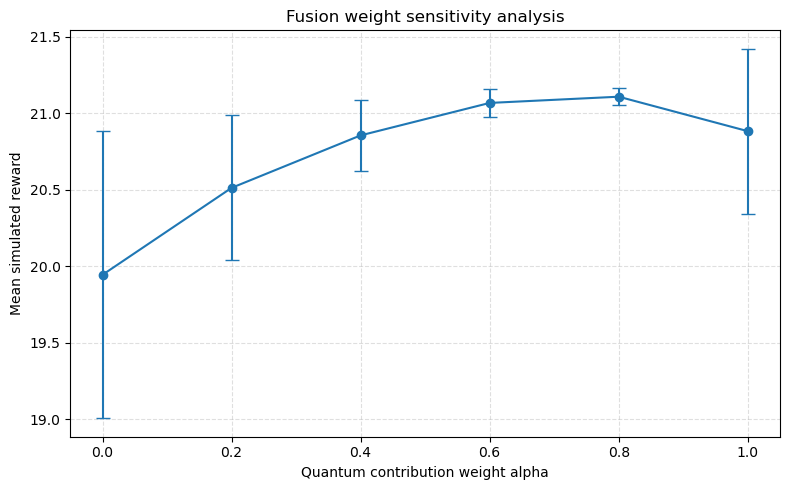

Saved: sepsis_asc_results\figures\fig_alpha_sensitivity_seed_ci95.png


In [24]:
# --- Paper-style alpha sensitivity with seed-level 95% CI ---

alpha_seed_rows = []

for model_name in eval_df["model"].unique():
    if model_name.startswith("Fusion-a"):
        alpha_value = float(model_name.split("a")[1])
        sub = (
            eval_df[eval_df["model"] == model_name]
            .groupby("seed")["reward"]
            .mean()
            .reset_index()
        )

        mean_val = sub["reward"].mean()
        std_val = sub["reward"].std()
        n_val = sub["reward"].count()
        se_val = std_val / np.sqrt(n_val)
        ci95 = 1.96 * se_val

        alpha_seed_rows.append({
            "alpha": alpha_value,
            "reward_mean": mean_val,
            "reward_std": std_val,
            "reward_se": se_val,
            "reward_ci95": ci95,
            "n_seeds": n_val,
        })

alpha_seed_df = pd.DataFrame(alpha_seed_rows).sort_values("alpha")
display(alpha_seed_df)

alpha_seed_path = os.path.join(RESULT_DIR, "alpha_sensitivity_seed_level.csv")
alpha_seed_df.to_csv(alpha_seed_path, index=False)

plt.figure(figsize=(8, 5))
plt.errorbar(
    alpha_seed_df["alpha"],
    alpha_seed_df["reward_mean"],
    yerr=alpha_seed_df["reward_ci95"],
    marker="o",
    capsize=5
)
plt.xlabel("Quantum contribution weight alpha")
plt.ylabel("Mean simulated reward")
plt.title("Fusion weight sensitivity analysis")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_alpha_sensitivity_seed_ci95.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

,model,reward_mean,reward_std,reward_se,reward_ci95,n_seeds
0,Random,-25.034000,1.484804,0.857252,1.680214,3
1,RuleBased,7.570333,0.373728,0.215772,0.422913,3
2,Small-DQN,17.181667,5.181146,2.991336,5.863019,3
3,Standard-DQN,19.945000,0.827950,0.478017,0.936913,3
4,VQC-DQN,20.883000,0.475236,0.274377,0.537780,3
5,Fusion-a0.8,21.108000,0.050715,0.029280,0.057389,3


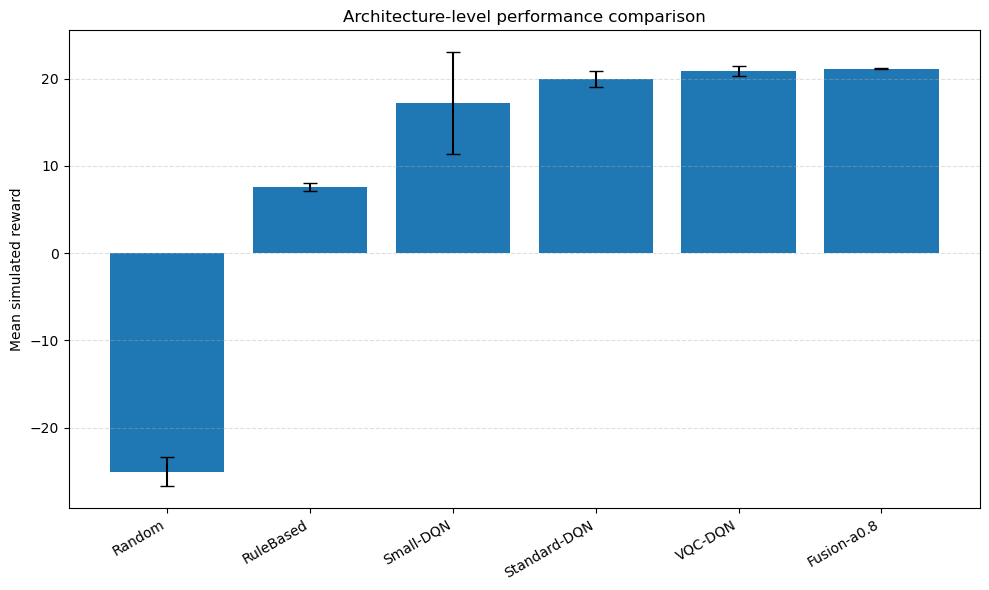

Saved: sepsis_asc_results\figures\fig_model_performance_seed_ci95.png


In [25]:
# --- Paper-style architecture comparison with seed-level 95% CI ---

preferred_order = [
    "Random",
    "RuleBased",
    "Small-DQN",
    "Standard-DQN",
    "VQC-DQN",
    "Fusion-a0.8",
]

seed_level = (
    eval_df
    .groupby(["seed", "model"])["reward"]
    .mean()
    .reset_index()
)

paper_summary_rows = []

for model_name in preferred_order:
    sub = seed_level[seed_level["model"] == model_name]
    if len(sub) == 0:
        continue

    mean_val = sub["reward"].mean()
    std_val = sub["reward"].std()
    n_val = sub["reward"].count()
    se_val = std_val / np.sqrt(n_val)
    ci95 = 1.96 * se_val

    paper_summary_rows.append({
        "model": model_name,
        "reward_mean": mean_val,
        "reward_std": std_val,
        "reward_se": se_val,
        "reward_ci95": ci95,
        "n_seeds": n_val,
    })

paper_summary = pd.DataFrame(paper_summary_rows)
display(paper_summary)

paper_summary_path = os.path.join(RESULT_DIR, "architecture_reward_seed_level.csv")
paper_summary.to_csv(paper_summary_path, index=False)

plt.figure(figsize=(10, 6))
plt.bar(
    paper_summary["model"],
    paper_summary["reward_mean"],
    yerr=paper_summary["reward_ci95"],
    capsize=5
)

plt.ylabel("Mean simulated reward")
plt.title("Architecture-level performance comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, "fig_model_performance_seed_ci95.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [28]:
# --- Noise robustness evaluation using already trained agents ---

NOISE_LEVELS = [0.00, 0.01, 0.02, 0.05, 0.10]

noise_rows = []

for seed in SEEDS:
    print(f"Noise robustness | seed={seed}")

    dqn_agent = trained_agents[seed]["Standard-DQN"]
    vqc_agent = trained_agents[seed]["VQC-DQN"]

    policies = {
        "RuleBased": rule_based_policy_fn,
        "Standard-DQN": agent_policy_fn(dqn_agent),
        "VQC-DQN": agent_policy_fn(vqc_agent),
        "Fusion-a0.8": fusion_policy_fn(vqc_agent, dqn_agent, alpha=0.8),
    }

    for noise_std in NOISE_LEVELS:
        env_kwargs_noise = ENV_KWARGS.copy()
        env_kwargs_noise["noise_std"] = noise_std
        env_kwargs_noise["reward_mode"] = "full"

        for model_name, policy in policies.items():
            df_tmp = evaluate_policy(
                model_name,
                policy,
                seed,
                env_kwargs_noise,
                eval_episodes_per_profile=EVAL_EPISODES_PER_PROFILE,
            )
            df_tmp["noise_std"] = noise_std
            noise_rows.append(df_tmp)

noise_df = pd.concat(noise_rows, ignore_index=True)

noise_path = os.path.join(RESULT_DIR, "noise_robustness_episode_metrics.csv")
noise_df.to_csv(noise_path, index=False)

print("Saved:", noise_path)
display(noise_df.head())

Noise robustness | seed=11
Noise robustness | seed=22
Noise robustness | seed=33
Saved: sepsis_asc_results\noise_robustness_episode_metrics.csv


,profile,reward,steps,terminal_bad,action_decrease_count,action_maintain_count,action_increase_count,map_target_ratio,hypotension_rate,severe_hypotension_rate,lactate_high_rate,action_switch_rate,model,seed,rep,noise_std
0,mild_risk,6.00,24,0.0,0,20,4,0.333333,0.0,0.0,0.0,0.333333,RuleBased,11,0,0.0
1,mild_risk,6.00,24,0.0,0,20,4,0.333333,0.0,0.0,0.0,0.333333,RuleBased,11,1,0.0
2,mild_risk,10.40,24,0.0,0,20,4,0.500000,0.0,0.0,0.0,0.333333,RuleBased,11,2,0.0
3,mild_risk,10.35,24,0.0,0,19,5,0.500000,0.0,0.0,0.0,0.375000,RuleBased,11,3,0.0
4,mild_risk,10.40,24,0.0,0,20,4,0.500000,0.0,0.0,0.0,0.333333,RuleBased,11,4,0.0


In [27]:
def evaluate_policy(
    model_label,
    policy_fn,
    seed,
    env_kwargs,
    eval_episodes_per_profile=10,
    profiles=None,
):
    if profiles is None:
        profiles = list(PATIENT_PROFILES.keys())

    # FIX: env_kwargs içinde zaten varsa çakışma yaratan alanları temizle
    clean_env_kwargs = env_kwargs.copy()
    clean_env_kwargs.pop("profile_mode", None)
    clean_env_kwargs.pop("default_profile", None)
    clean_env_kwargs.pop("seed", None)

    rows = []

    for profile in profiles:
        for rep in range(eval_episodes_per_profile):
            env_seed = 100000 + seed * 1000 + rep

            env = SepsisTitrationEnv(
                **clean_env_kwargs,
                profile_mode="fixed",
                default_profile=profile,
                seed=env_seed,
            )

            row = run_eval_episode(env, policy_fn, profile)
            row["model"] = model_label
            row["seed"] = seed
            row["rep"] = rep
            rows.append(row)

    return pd.DataFrame(rows)

print("evaluate_policy fonksiyonu düzeltildi.")

evaluate_policy fonksiyonu düzeltildi.


In [29]:
# ============================================================
# FINAL ASC EXPERIMENT CONFIGURATION
# ============================================================

FINAL_RUN_NAME = "asc_final_30seed"
FINAL_RESULT_DIR = os.path.join(RESULT_DIR, FINAL_RUN_NAME)
FINAL_FIG_DIR = os.path.join(FINAL_RESULT_DIR, "figures")
FINAL_MODEL_DIR = os.path.join(FINAL_RESULT_DIR, "saved_agents")

os.makedirs(FINAL_RESULT_DIR, exist_ok=True)
os.makedirs(FINAL_FIG_DIR, exist_ok=True)
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

FINAL_SEEDS = list(range(1, 31))       # makale için 30 seed
FINAL_EPISODES = 400
FINAL_EVAL_EPISODES_PER_PROFILE = 20

FINAL_ALPHA_GRID = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
FINAL_MAIN_ALPHA = 0.8

FINAL_ENV_KWARGS = {
    "profiles": PATIENT_PROFILES,
    "profile_mode": "random",
    "default_profile": "moderate_risk",
    "horizon": HORIZON,
    "noise_std": DEFAULT_NOISE_STD,
    "init_jitter": INIT_JITTER,
    "reward_mode": "full",
}

print("Final run:", FINAL_RUN_NAME)
print("Seeds:", FINAL_SEEDS[:5], "...", FINAL_SEEDS[-5:])
print("Episodes:", FINAL_EPISODES)
print("Evaluation episodes/profile:", FINAL_EVAL_EPISODES_PER_PROFILE)

Final run: asc_final_30seed
Seeds: [1, 2, 3, 4, 5] ... [26, 27, 28, 29, 30]
Episodes: 400
Evaluation episodes/profile: 20


In [30]:
# ============================================================
# CHECKPOINT HELPERS
# ============================================================

MODEL_FACTORIES = {
    "Small-DQN": lambda: ClassicalQNet(hidden_sizes=(16, 8)),
    "Standard-DQN": lambda: ClassicalQNet(hidden_sizes=(64, 64)),
    "VQC-DQN": lambda: VQCQNet(n_qubits=4, n_layers=3),
}

def agent_checkpoint_path(model_name, seed):
    safe_name = model_name.replace("/", "_")
    return os.path.join(FINAL_MODEL_DIR, f"{safe_name}_seed{seed}.pt")

def history_checkpoint_path(model_name, seed):
    safe_name = model_name.replace("/", "_")
    return os.path.join(FINAL_RESULT_DIR, f"history_{safe_name}_seed{seed}.csv")

def eval_checkpoint_path(seed):
    return os.path.join(FINAL_RESULT_DIR, f"evaluation_seed{seed}.csv")

def save_agent(agent, model_name, seed):
    path = agent_checkpoint_path(model_name, seed)
    torch.save(agent.model.state_dict(), path)
    return path

def load_agent(model_name, seed):
    path = agent_checkpoint_path(model_name, seed)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Checkpoint not found: {path}")

    model = MODEL_FACTORIES[model_name]()
    agent = DQNAgent(
        model=model,
        lr=LR,
        gamma=GAMMA,
        batch_size=BATCH_SIZE,
        memory_size=MEMORY_SIZE,
        epsilon_start=EPSILON_MIN,
        epsilon_min=EPSILON_MIN,
        epsilon_decay=EPSILON_DECAY,
        device=DEVICE,
    )

    state_dict = torch.load(path, map_location=DEVICE)
    agent.model.load_state_dict(state_dict)
    agent.update_target()
    agent.epsilon = EPSILON_MIN
    return agent

print("Checkpoint helpers ready.")

Checkpoint helpers ready.


In [31]:
# ============================================================
# FINAL MAIN TRAINING + EVALUATION
# ============================================================

final_histories = []
final_evaluations = []
final_trained_agents = {}

for seed in FINAL_SEEDS:
    print("\n" + "=" * 90)
    print(f"FINAL SEED {seed}")
    print("=" * 90)

    seed_eval_path = eval_checkpoint_path(seed)

    # Eğer bu seed daha önce tamamlandıysa CSV'den yükle
    if os.path.exists(seed_eval_path):
        print(f"Seed {seed} evaluation already exists. Loading:", seed_eval_path)
        seed_eval_df = pd.read_csv(seed_eval_path)
        final_evaluations.append(seed_eval_df)

        # Modelleri de yüklemeyi dene
        try:
            final_trained_agents[seed] = {
                "Small-DQN": load_agent("Small-DQN", seed),
                "Standard-DQN": load_agent("Standard-DQN", seed),
                "VQC-DQN": load_agent("VQC-DQN", seed),
            }
        except Exception as e:
            print("Agent loading warning:", e)

        continue

    set_global_seed(seed)
    seed_eval_rows = []
    seed_hist_rows = []

    # 1) Non-learning baselines
    random_eval = evaluate_policy(
        "Random",
        random_policy_fn,
        seed,
        FINAL_ENV_KWARGS,
        eval_episodes_per_profile=FINAL_EVAL_EPISODES_PER_PROFILE,
    )
    seed_eval_rows.append(random_eval)

    rule_eval = evaluate_policy(
        "RuleBased",
        rule_based_policy_fn,
        seed,
        FINAL_ENV_KWARGS,
        eval_episodes_per_profile=FINAL_EVAL_EPISODES_PER_PROFILE,
    )
    seed_eval_rows.append(rule_eval)

    # 2) Trainable agents
    trained_this_seed = {}

    for model_name, factory in MODEL_FACTORIES.items():
        ckpt_path = agent_checkpoint_path(model_name, seed)
        hist_path = history_checkpoint_path(model_name, seed)

        if os.path.exists(ckpt_path) and os.path.exists(hist_path):
            print(f"Loading existing {model_name}, seed={seed}")
            agent = load_agent(model_name, seed)
            hist_df_tmp = pd.read_csv(hist_path)
        else:
            agent, hist_df_tmp = train_agent(
                model_name,
                factory,
                seed,
                FINAL_ENV_KWARGS,
                episodes=FINAL_EPISODES,
            )
            save_agent(agent, model_name, seed)
            hist_df_tmp.to_csv(hist_path, index=False)

        trained_this_seed[model_name] = agent
        seed_hist_rows.append(hist_df_tmp)

        eval_tmp = evaluate_policy(
            model_name,
            agent_policy_fn(agent),
            seed,
            FINAL_ENV_KWARGS,
            eval_episodes_per_profile=FINAL_EVAL_EPISODES_PER_PROFILE,
        )
        seed_eval_rows.append(eval_tmp)

    # 3) Real fusion using trained Standard-DQN + VQC-DQN
    dqn_agent = trained_this_seed["Standard-DQN"]
    vqc_agent = trained_this_seed["VQC-DQN"]

    for alpha in FINAL_ALPHA_GRID:
        fusion_label = f"Fusion-a{alpha:.1f}"
        fusion_eval = evaluate_policy(
            fusion_label,
            fusion_policy_fn(vqc_agent, dqn_agent, alpha=alpha),
            seed,
            FINAL_ENV_KWARGS,
            eval_episodes_per_profile=FINAL_EVAL_EPISODES_PER_PROFILE,
        )
        seed_eval_rows.append(fusion_eval)

    # Save seed-level outputs
    seed_eval_df = pd.concat(seed_eval_rows, ignore_index=True)
    seed_eval_df.to_csv(seed_eval_path, index=False)

    seed_hist_df = pd.concat(seed_hist_rows, ignore_index=True)
    seed_hist_df.to_csv(os.path.join(FINAL_RESULT_DIR, f"training_history_seed{seed}.csv"), index=False)

    final_evaluations.append(seed_eval_df)
    final_histories.append(seed_hist_df)
    final_trained_agents[seed] = trained_this_seed

# Combine all completed seeds
eval_df_final = pd.concat(final_evaluations, ignore_index=True)

# histories may be empty if all were loaded; reload from files
history_files = [
    os.path.join(FINAL_RESULT_DIR, f)
    for f in os.listdir(FINAL_RESULT_DIR)
    if f.startswith("training_history_seed") and f.endswith(".csv")
]
hist_df_final = pd.concat([pd.read_csv(f) for f in history_files], ignore_index=True)

eval_final_path = os.path.join(FINAL_RESULT_DIR, "FINAL_evaluation_episode_metrics.csv")
hist_final_path = os.path.join(FINAL_RESULT_DIR, "FINAL_training_history.csv")

eval_df_final.to_csv(eval_final_path, index=False)
hist_df_final.to_csv(hist_final_path, index=False)

print("Saved:", eval_final_path)
print("Saved:", hist_final_path)

display(eval_df_final.head())


FINAL SEED 1
Small-DQN | seed=1 | ep=000/400 | reward=-25.10 | eps=0.990
Small-DQN | seed=1 | ep=020/400 | reward=-7.85 | eps=0.810
Small-DQN | seed=1 | ep=040/400 | reward=-26.85 | eps=0.662
Small-DQN | seed=1 | ep=060/400 | reward=15.50 | eps=0.542
Small-DQN | seed=1 | ep=080/400 | reward=-4.10 | eps=0.443
Small-DQN | seed=1 | ep=100/400 | reward=10.65 | eps=0.362
Small-DQN | seed=1 | ep=120/400 | reward=15.90 | eps=0.296
Small-DQN | seed=1 | ep=140/400 | reward=6.50 | eps=0.242
Small-DQN | seed=1 | ep=160/400 | reward=16.70 | eps=0.198
Small-DQN | seed=1 | ep=180/400 | reward=18.00 | eps=0.162
Small-DQN | seed=1 | ep=200/400 | reward=21.25 | eps=0.133
Small-DQN | seed=1 | ep=220/400 | reward=16.75 | eps=0.108
Small-DQN | seed=1 | ep=240/400 | reward=17.80 | eps=0.089
Small-DQN | seed=1 | ep=260/400 | reward=19.05 | eps=0.073
Small-DQN | seed=1 | ep=280/400 | reward=17.00 | eps=0.059
Small-DQN | seed=1 | ep=300/400 | reward=20.20 | eps=0.050
Small-DQN | seed=1 | ep=320/400 | reward=

,profile,reward,steps,terminal_bad,action_decrease_count,action_maintain_count,action_increase_count,map_target_ratio,hypotension_rate,severe_hypotension_rate,lactate_high_rate,action_switch_rate,model,seed,rep
0,mild_risk,-45.85,12,1.0,5,5,2,0.000000,0.666667,0.083333,0.0,0.750000,Random,1,0
1,mild_risk,-22.00,17,1.0,7,6,4,0.000000,0.176471,0.058824,0.0,0.705882,Random,1,1
2,mild_risk,3.15,24,0.0,8,8,8,0.250000,0.000000,0.000000,0.0,0.875000,Random,1,2
3,mild_risk,-17.10,24,0.0,5,7,12,0.125000,0.000000,0.000000,0.0,0.750000,Random,1,3
4,mild_risk,8.95,24,0.0,5,9,10,0.458333,0.000000,0.000000,0.0,0.625000,Random,1,4


In [32]:
# ============================================================
# FINAL SUMMARY TABLES
# ============================================================

final_summary = (
    eval_df_final
    .groupby("model")
    .agg(
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        reward_median=("reward", "median"),
        map_target_ratio=("map_target_ratio", "mean"),
        hypotension_rate=("hypotension_rate", "mean"),
        severe_hypotension_rate=("severe_hypotension_rate", "mean"),
        lactate_high_rate=("lactate_high_rate", "mean"),
        action_switch_rate=("action_switch_rate", "mean"),
        terminal_bad_rate=("terminal_bad", "mean"),
        mean_steps=("steps", "mean"),
    )
    .sort_values("reward_mean", ascending=False)
)

final_summary_path = os.path.join(FINAL_RESULT_DIR, "FINAL_summary_by_model.csv")
final_summary.to_csv(final_summary_path)

display(final_summary)
print("Saved:", final_summary_path)


final_profile_summary = (
    eval_df_final
    .groupby(["model", "profile"])
    .agg(
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        map_target_ratio=("map_target_ratio", "mean"),
        hypotension_rate=("hypotension_rate", "mean"),
        lactate_high_rate=("lactate_high_rate", "mean"),
        action_switch_rate=("action_switch_rate", "mean"),
        terminal_bad_rate=("terminal_bad", "mean"),
    )
    .reset_index()
    .sort_values(["profile", "reward_mean"], ascending=[True, False])
)

final_profile_path = os.path.join(FINAL_RESULT_DIR, "FINAL_summary_by_profile.csv")
final_profile_summary.to_csv(final_profile_path, index=False)

display(final_profile_summary.head(30))
print("Saved:", final_profile_path)

,reward_mean,reward_std,reward_median,map_target_ratio,hypotension_rate,severe_hypotension_rate,lactate_high_rate,action_switch_rate,terminal_bad_rate,mean_steps
model,,,,,,,,,,
Fusion-a0.4,20.736550,3.005337,21.35,0.919403,0.004333,0.000000,0.004514,0.431458,0.000000,24.000000
Fusion-a0.2,20.707317,3.038491,21.35,0.918639,0.004333,0.000000,0.004500,0.439292,0.000000,24.000000
Fusion-a0.6,20.640300,3.013667,21.30,0.915458,0.004333,0.000000,0.004514,0.424889,0.000000,24.000000
Fusion-a0.0,20.553367,3.091128,21.30,0.913264,0.004333,0.000000,0.004500,0.449333,0.000000,24.000000
Standard-DQN,20.553367,3.091128,21.30,0.913264,0.004333,0.000000,0.004500,0.449333,0.000000,24.000000
Fusion-a0.8,20.417467,3.083706,21.25,0.907097,0.004333,0.000000,0.004514,0.424528,0.000000,24.000000
Fusion-a1.0,20.044083,3.360839,21.00,0.894222,0.004333,0.000000,0.004514,0.428681,0.000000,24.000000
VQC-DQN,20.044083,3.360839,21.00,0.894222,0.004333,0.000000,0.004514,0.428681,0.000000,24.000000
Small-DQN,18.354683,5.941732,20.10,0.835375,0.008972,0.000976,0.008764,0.403681,0.004667,23.913333


Saved: sepsis_asc_results\asc_final_30seed\FINAL_summary_by_model.csv


,model,profile,reward_mean,reward_std,map_target_ratio,hypotension_rate,lactate_high_rate,action_switch_rate,terminal_bad_rate
10,Fusion-a0.4,high_risk,20.299750,1.037222,0.879306,0.000000,0.000000,0.428264,0.000000
5,Fusion-a0.2,high_risk,20.252333,1.072915,0.877917,0.000000,0.000000,0.437222,0.000000
15,Fusion-a0.6,high_risk,20.230750,1.080283,0.876458,0.000000,0.000000,0.423125,0.000000
0,Fusion-a0.0,high_risk,20.131500,1.192639,0.873750,0.000000,0.000000,0.446250,0.000000
45,Standard-DQN,high_risk,20.131500,1.192639,0.873750,0.000000,0.000000,0.446250,0.000000
20,Fusion-a0.8,high_risk,20.021167,1.194706,0.868611,0.000000,0.000000,0.422500,0.000000
25,Fusion-a1.0,high_risk,19.729667,1.399086,0.857847,0.000000,0.000000,0.425972,0.000000
50,VQC-DQN,high_risk,19.729667,1.399086,0.857847,0.000000,0.000000,0.425972,0.000000
40,Small-DQN,high_risk,18.496750,3.826523,0.811319,0.000000,0.000000,0.398125,0.000000
35,RuleBased,high_risk,7.500917,2.869559,0.391667,0.000000,0.000000,0.365903,0.000000


Saved: sepsis_asc_results\asc_final_30seed\FINAL_summary_by_profile.csv


In [33]:
# ============================================================
# SEED-LEVEL SUMMARY WITH 95% CI
# ============================================================

seed_level_final = (
    eval_df_final
    .groupby(["seed", "model"])["reward"]
    .mean()
    .reset_index()
)

paper_models = [
    "Random",
    "RuleBased",
    "Small-DQN",
    "Standard-DQN",
    "VQC-DQN",
    f"Fusion-a{FINAL_MAIN_ALPHA:.1f}",
]

paper_rows = []

for model_name in paper_models:
    sub = seed_level_final[seed_level_final["model"] == model_name]
    if len(sub) == 0:
        continue

    mean_val = sub["reward"].mean()
    std_val = sub["reward"].std()
    n_val = sub["reward"].count()
    se_val = std_val / np.sqrt(n_val)
    ci95 = 1.96 * se_val

    paper_rows.append({
        "model": model_name,
        "mean_reward": mean_val,
        "std_reward": std_val,
        "se_reward": se_val,
        "ci95_reward": ci95,
        "n_seeds": n_val,
    })

paper_reward_summary = pd.DataFrame(paper_rows)

paper_reward_path = os.path.join(FINAL_RESULT_DIR, "FINAL_seed_level_reward_summary.csv")
paper_reward_summary.to_csv(paper_reward_path, index=False)

display(paper_reward_summary)
print("Saved:", paper_reward_path)

,model,mean_reward,std_reward,se_reward,ci95_reward,n_seeds
0,Random,-22.866017,2.451351,0.447553,0.877205,30
1,RuleBased,7.551300,0.622608,0.113672,0.222798,30
2,Small-DQN,18.354683,2.185111,0.398945,0.781932,30
3,Standard-DQN,20.553367,0.599087,0.109378,0.214380,30
4,VQC-DQN,20.044083,0.709447,0.129527,0.253872,30
5,Fusion-a0.8,20.417467,0.534750,0.097631,0.191358,30


Saved: sepsis_asc_results\asc_final_30seed\FINAL_seed_level_reward_summary.csv


In [34]:
# ============================================================
# FINAL STATISTICAL TESTS
# ============================================================

seed_model_reward_final = (
    eval_df_final
    .groupby(["seed", "model"])["reward"]
    .mean()
    .unstack()
)

display(seed_model_reward_final.head())

stat_models = [
    "Random",
    "RuleBased",
    "Small-DQN",
    "Standard-DQN",
    "VQC-DQN",
    f"Fusion-a{FINAL_MAIN_ALPHA:.1f}",
]

available_stat_models = [m for m in stat_models if m in seed_model_reward_final.columns]

arrays = [seed_model_reward_final[m].dropna().values for m in available_stat_models]

friedman_stat, friedman_p = friedmanchisquare(*arrays)

print("Friedman test")
print("Models:", available_stat_models)
print("Statistic:", friedman_stat)
print("p-value:", friedman_p)

# Pairwise Wilcoxon versus main fusion
main_fusion_label = f"Fusion-a{FINAL_MAIN_ALPHA:.1f}"
pairwise_rows = []

if main_fusion_label in seed_model_reward_final.columns:
    base = seed_model_reward_final[main_fusion_label].values

    for m in available_stat_models:
        if m == main_fusion_label:
            continue

        comp = seed_model_reward_final[m].values

        try:
            w_stat, w_p = wilcoxon(base, comp, zero_method="wilcox", alternative="two-sided")
        except Exception:
            w_stat, w_p = np.nan, np.nan

        diff = base - comp

        pairwise_rows.append({
            "comparison": f"{main_fusion_label} vs {m}",
            "wilcoxon_stat": w_stat,
            "p_value_raw": w_p,
            "fusion_mean": np.mean(base),
            "other_mean": np.mean(comp),
            "mean_difference": np.mean(diff),
            "median_difference": np.median(diff),
            "percent_gain_over_other": 100 * (np.mean(base) - np.mean(comp)) / (abs(np.mean(comp)) + 1e-8),
        })

pairwise_df = pd.DataFrame(pairwise_rows)

# Holm correction
pairwise_df = pairwise_df.sort_values("p_value_raw").reset_index(drop=True)
m_tests = len(pairwise_df)
holm_values = []
for i, p in enumerate(pairwise_df["p_value_raw"].values):
    holm_values.append(min((m_tests - i) * p, 1.0))

# monotonic Holm adjustment
holm_values = np.maximum.accumulate(holm_values)
pairwise_df["p_value_holm"] = holm_values

stats_path = os.path.join(FINAL_RESULT_DIR, "FINAL_pairwise_wilcoxon_vs_fusion.csv")
pairwise_df.to_csv(stats_path, index=False)

display(pairwise_df)

friedman_path = os.path.join(FINAL_RESULT_DIR, "FINAL_friedman_test.txt")
with open(friedman_path, "w") as f:
    f.write(f"Models: {available_stat_models}\n")
    f.write(f"Friedman statistic: {friedman_stat}\n")
    f.write(f"p-value: {friedman_p}\n")

print("Saved:", stats_path)
print("Saved:", friedman_path)

model,Fusion-a0.0,Fusion-a0.2,Fusion-a0.4,Fusion-a0.6,Fusion-a0.8,Fusion-a1.0,Random,RuleBased,Small-DQN,Standard-DQN,VQC-DQN
seed,,,,,,,,,,,
1,21.3865,21.2775,21.1420,20.6170,19.8815,19.1005,-20.1270,8.8790,18.5095,21.3865,19.1005
2,21.0945,21.1405,21.0605,20.9440,20.8055,20.6015,-19.5035,7.2325,18.8470,21.0945,20.6015
3,20.8825,20.8785,20.8240,20.7870,20.7435,20.6595,-24.0110,7.1655,17.6300,20.8825,20.6595
4,20.9925,21.1765,21.1370,21.1955,21.1040,21.0555,-22.6755,8.8725,19.2890,20.9925,21.0555
5,20.6130,20.8785,20.8930,20.6695,20.3540,20.0575,-28.3885,6.5130,15.8360,20.6130,20.0575


Friedman test
Models: ['Random', 'RuleBased', 'Small-DQN', 'Standard-DQN', 'VQC-DQN', 'Fusion-a0.8']
Statistic: 131.6952380952382
p-value: 1.0393728856234913e-26


,comparison,wilcoxon_stat,p_value_raw,fusion_mean,other_mean,mean_difference,median_difference,percent_gain_over_other,p_value_holm
0,Fusion-a0.8 vs RuleBased,0.0,1.862645e-09,20.417467,7.551300,12.866167,12.91900,170.383466,9.313226e-09
1,Fusion-a0.8 vs VQC-DQN,0.0,1.862645e-09,20.417467,20.044083,0.373383,0.26300,1.862811,9.313226e-09
2,Fusion-a0.8 vs Small-DQN,17.0,3.855675e-07,20.417467,18.354683,2.062783,1.33525,11.238458,1.156703e-06
3,Fusion-a0.8 vs Random,0.0,1.733307e-06,20.417467,-22.866017,43.283483,43.35875,189.291751,3.466613e-06
4,Fusion-a0.8 vs Standard-DQN,130.0,3.453673e-02,20.417467,20.553367,-0.135900,-0.20425,-0.661206,3.453673e-02


Saved: sepsis_asc_results\asc_final_30seed\FINAL_pairwise_wilcoxon_vs_fusion.csv
Saved: sepsis_asc_results\asc_final_30seed\FINAL_friedman_test.txt


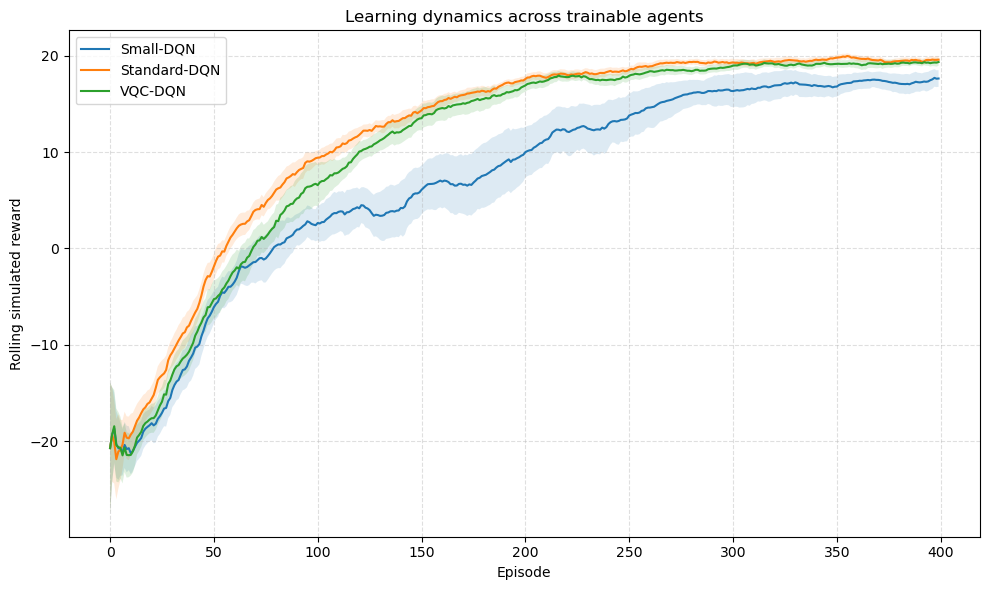

Saved: sepsis_asc_results\asc_final_30seed\figures\FINAL_fig_learning_curves_ci95.png


In [35]:
# ============================================================
# FINAL FIGURE: LEARNING CURVES
# ============================================================

hist_plot_final = hist_df_final.copy()

hist_plot_final["rolling_reward"] = (
    hist_plot_final
    .groupby(["model", "seed"])["episode_reward"]
    .transform(lambda x: x.rolling(window=20, min_periods=1).mean())
)

curve_seed = (
    hist_plot_final
    .groupby(["model", "seed", "episode"])["rolling_reward"]
    .mean()
    .reset_index()
)

curve_summary = (
    curve_seed
    .groupby(["model", "episode"])
    .agg(
        mean_reward=("rolling_reward", "mean"),
        std_reward=("rolling_reward", "std"),
        n=("rolling_reward", "count"),
    )
    .reset_index()
)

curve_summary["ci95"] = 1.96 * curve_summary["std_reward"] / np.sqrt(curve_summary["n"])

plt.figure(figsize=(10, 6))

for model_name in ["Small-DQN", "Standard-DQN", "VQC-DQN"]:
    sub = curve_summary[curve_summary["model"] == model_name]
    if len(sub) == 0:
        continue

    plt.plot(sub["episode"], sub["mean_reward"], label=model_name)
    plt.fill_between(
        sub["episode"],
        sub["mean_reward"] - sub["ci95"].fillna(0),
        sub["mean_reward"] + sub["ci95"].fillna(0),
        alpha=0.15,
    )

plt.xlabel("Episode")
plt.ylabel("Rolling simulated reward")
plt.title("Learning dynamics across trainable agents")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FINAL_FIG_DIR, "FINAL_fig_learning_curves_ci95.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

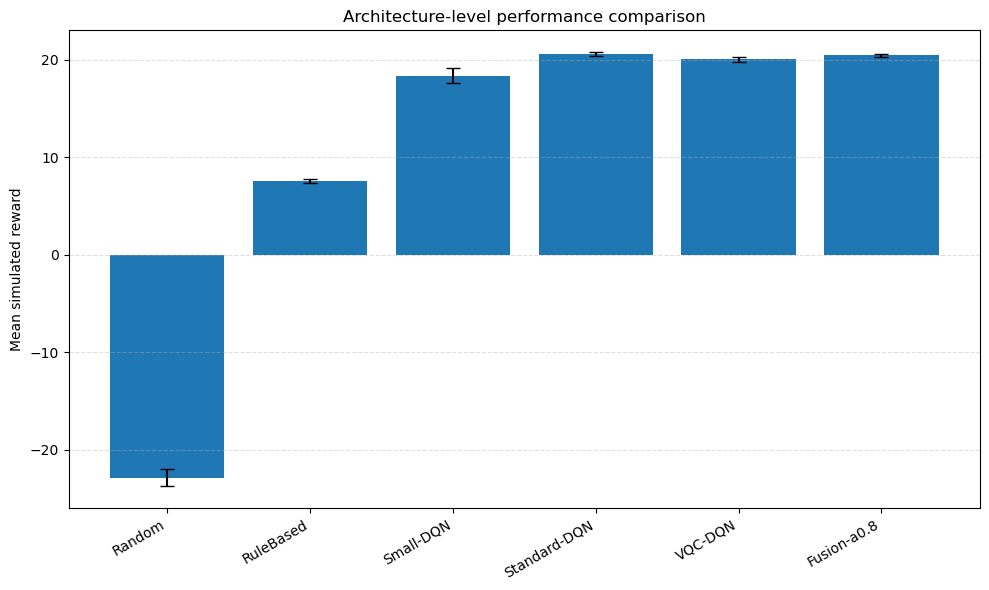

Saved: sepsis_asc_results\asc_final_30seed\figures\FINAL_fig_model_performance_ci95.png


In [36]:
# ============================================================
# FINAL FIGURE: ARCHITECTURE-LEVEL PERFORMANCE
# ============================================================

plot_df = paper_reward_summary.copy()
plot_df["model"] = pd.Categorical(plot_df["model"], categories=paper_models, ordered=True)
plot_df = plot_df.sort_values("model")

plt.figure(figsize=(10, 6))
plt.bar(
    plot_df["model"].astype(str),
    plot_df["mean_reward"],
    yerr=plot_df["ci95_reward"],
    capsize=5,
)

plt.ylabel("Mean simulated reward")
plt.title("Architecture-level performance comparison")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FINAL_FIG_DIR, "FINAL_fig_model_performance_ci95.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

,model,map_target_ratio,hypotension_rate,lactate_high_rate,action_switch_rate,terminal_bad_rate
0,Random,0.138186,0.419081,0.117035,0.661783,0.555667
1,RuleBased,0.416194,0.004333,0.004500,0.348861,0.000000
2,Small-DQN,0.835375,0.008972,0.008764,0.403681,0.004667
3,Standard-DQN,0.913264,0.004333,0.004500,0.449333,0.000000
4,VQC-DQN,0.894222,0.004333,0.004514,0.428681,0.000000
5,Fusion-a0.8,0.907097,0.004333,0.004514,0.424528,0.000000


Saved: sepsis_asc_results\asc_final_30seed\FINAL_safety_metrics_table.csv


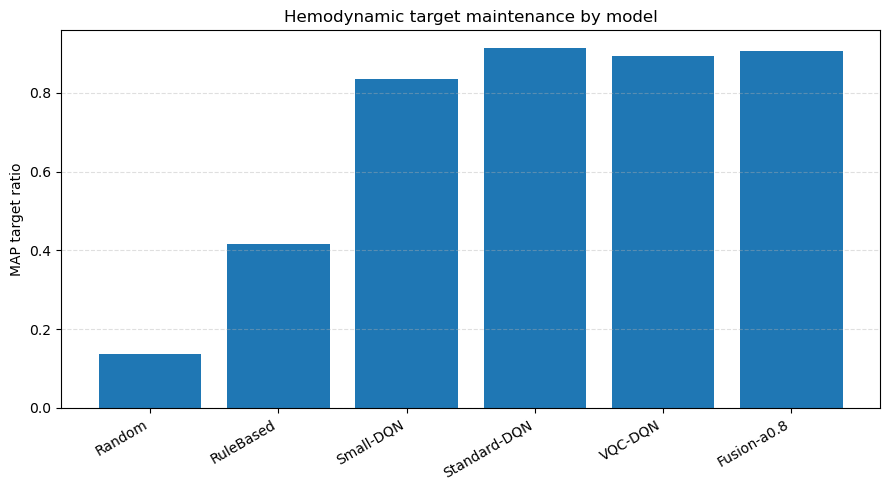

Saved: sepsis_asc_results\asc_final_30seed\figures\FINAL_fig_map_target_ratio.png


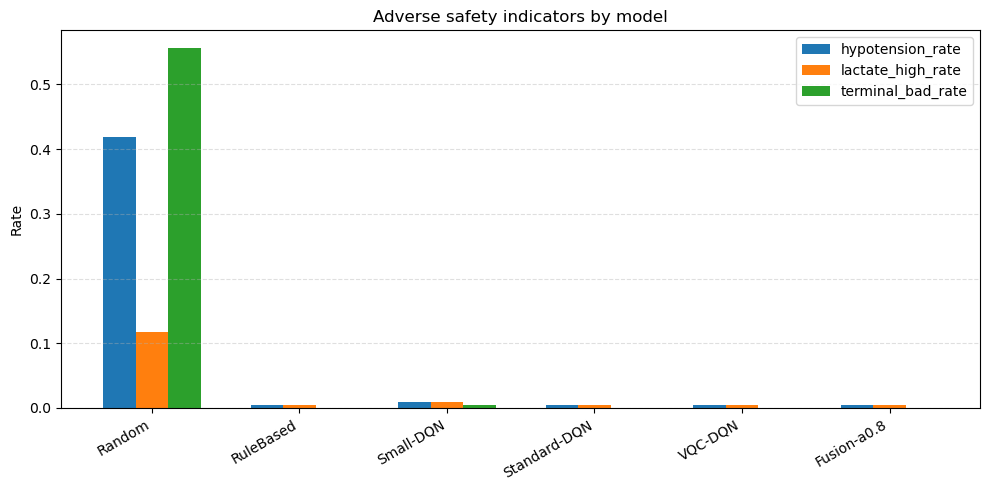

Saved: sepsis_asc_results\asc_final_30seed\figures\FINAL_fig_adverse_safety_metrics.png


In [37]:
# ============================================================
# FINAL FIGURE: SAFETY METRICS
# ============================================================

safety_models = [m for m in paper_models if m in final_summary.index]

safety_df_final = final_summary.loc[safety_models, [
    "map_target_ratio",
    "hypotension_rate",
    "lactate_high_rate",
    "action_switch_rate",
    "terminal_bad_rate",
]].reset_index()

safety_path = os.path.join(FINAL_RESULT_DIR, "FINAL_safety_metrics_table.csv")
safety_df_final.to_csv(safety_path, index=False)

display(safety_df_final)
print("Saved:", safety_path)

# Daha temiz makale grafiği: MAP hedef oranı ayrı
plt.figure(figsize=(9, 5))
plt.bar(safety_df_final["model"], safety_df_final["map_target_ratio"])
plt.ylabel("MAP target ratio")
plt.title("Hemodynamic target maintenance by model")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FINAL_FIG_DIR, "FINAL_fig_map_target_ratio.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

# Adverse event metrics ayrı
adverse_cols = ["hypotension_rate", "lactate_high_rate", "terminal_bad_rate"]
x = np.arange(len(safety_df_final["model"]))
width = 0.22

plt.figure(figsize=(10, 5))

for i, metric in enumerate(adverse_cols):
    plt.bar(x + i * width, safety_df_final[metric], width=width, label=metric)

plt.xticks(x + width, safety_df_final["model"], rotation=30, ha="right")
plt.ylabel("Rate")
plt.title("Adverse safety indicators by model")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FINAL_FIG_DIR, "FINAL_fig_adverse_safety_metrics.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

,alpha,reward_mean,reward_std,reward_se,reward_ci95,n_seeds
0,0.0,20.553367,0.599087,0.109378,0.214380,30
1,0.2,20.707317,0.459130,0.083825,0.164298,30
2,0.4,20.736550,0.377451,0.068913,0.135069,30
3,0.6,20.640300,0.426551,0.077877,0.152639,30
4,0.8,20.417467,0.534750,0.097631,0.191358,30
5,1.0,20.044083,0.709447,0.129527,0.253872,30


Saved: sepsis_asc_results\asc_final_30seed\FINAL_alpha_sensitivity_seed_level.csv


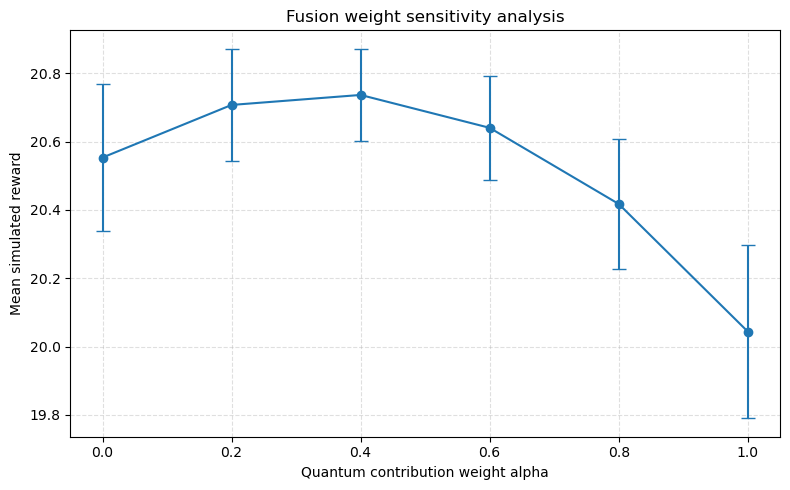

Saved: sepsis_asc_results\asc_final_30seed\figures\FINAL_fig_alpha_sensitivity_ci95.png


In [38]:
# ============================================================
# FINAL FIGURE: ALPHA SENSITIVITY
# ============================================================

alpha_seed_rows_final = []

for model_name in eval_df_final["model"].unique():
    if model_name.startswith("Fusion-a"):
        alpha_value = float(model_name.split("a")[1])
        sub = (
            eval_df_final[eval_df_final["model"] == model_name]
            .groupby("seed")["reward"]
            .mean()
            .reset_index()
        )

        mean_val = sub["reward"].mean()
        std_val = sub["reward"].std()
        n_val = sub["reward"].count()
        se_val = std_val / np.sqrt(n_val)
        ci95 = 1.96 * se_val

        alpha_seed_rows_final.append({
            "alpha": alpha_value,
            "reward_mean": mean_val,
            "reward_std": std_val,
            "reward_se": se_val,
            "reward_ci95": ci95,
            "n_seeds": n_val,
        })

alpha_final_df = pd.DataFrame(alpha_seed_rows_final).sort_values("alpha")

alpha_final_path = os.path.join(FINAL_RESULT_DIR, "FINAL_alpha_sensitivity_seed_level.csv")
alpha_final_df.to_csv(alpha_final_path, index=False)

display(alpha_final_df)
print("Saved:", alpha_final_path)

plt.figure(figsize=(8, 5))
plt.errorbar(
    alpha_final_df["alpha"],
    alpha_final_df["reward_mean"],
    yerr=alpha_final_df["reward_ci95"],
    marker="o",
    capsize=5,
)

plt.xlabel("Quantum contribution weight alpha")
plt.ylabel("Mean simulated reward")
plt.title("Fusion weight sensitivity analysis")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

fig_path = os.path.join(FINAL_FIG_DIR, "FINAL_fig_alpha_sensitivity_ci95.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [39]:
# ============================================================
# FINAL NOISE ROBUSTNESS
# ============================================================

NOISE_LEVELS_FINAL = [0.00, 0.01, 0.02, 0.05, 0.10]

noise_rows_final = []

for seed in FINAL_SEEDS:
    print(f"Noise robustness | seed={seed}")

    # ajanlar bellekte yoksa diskten yükle
    if seed in final_trained_agents and "Standard-DQN" in final_trained_agents[seed]:
        dqn_agent = final_trained_agents[seed]["Standard-DQN"]
        vqc_agent = final_trained_agents[seed]["VQC-DQN"]
    else:
        dqn_agent = load_agent("Standard-DQN", seed)
        vqc_agent = load_agent("VQC-DQN", seed)

    policies = {
        "RuleBased": rule_based_policy_fn,
        "Standard-DQN": agent_policy_fn(dqn_agent),
        "VQC-DQN": agent_policy_fn(vqc_agent),
        f"Fusion-a{FINAL_MAIN_ALPHA:.1f}": fusion_policy_fn(vqc_agent, dqn_agent, alpha=FINAL_MAIN_ALPHA),
    }

    for noise_std in NOISE_LEVELS_FINAL:
        env_kwargs_noise = FINAL_ENV_KWARGS.copy()
        env_kwargs_noise["noise_std"] = noise_std
        env_kwargs_noise["reward_mode"] = "full"

        for model_name, policy in policies.items():
            df_tmp = evaluate_policy(
                model_name,
                policy,
                seed,
                env_kwargs_noise,
                eval_episodes_per_profile=FINAL_EVAL_EPISODES_PER_PROFILE,
            )
            df_tmp["noise_std"] = noise_std
            noise_rows_final.append(df_tmp)

noise_df_final = pd.concat(noise_rows_final, ignore_index=True)

noise_final_path = os.path.join(FINAL_RESULT_DIR, "FINAL_noise_robustness_episode_metrics.csv")
noise_df_final.to_csv(noise_final_path, index=False)

display(noise_df_final.head())
print("Saved:", noise_final_path)

Noise robustness | seed=1
Noise robustness | seed=2
Noise robustness | seed=3
Noise robustness | seed=4
Noise robustness | seed=5
Noise robustness | seed=6
Noise robustness | seed=7
Noise robustness | seed=8
Noise robustness | seed=9
Noise robustness | seed=10
Noise robustness | seed=11
Noise robustness | seed=12
Noise robustness | seed=13
Noise robustness | seed=14
Noise robustness | seed=15
Noise robustness | seed=16
Noise robustness | seed=17
Noise robustness | seed=18
Noise robustness | seed=19
Noise robustness | seed=20
Noise robustness | seed=21
Noise robustness | seed=22
Noise robustness | seed=23
Noise robustness | seed=24
Noise robustness | seed=25
Noise robustness | seed=26
Noise robustness | seed=27
Noise robustness | seed=28
Noise robustness | seed=29
Noise robustness | seed=30


,profile,reward,steps,terminal_bad,action_decrease_count,action_maintain_count,action_increase_count,map_target_ratio,hypotension_rate,severe_hypotension_rate,lactate_high_rate,action_switch_rate,model,seed,rep,noise_std
0,mild_risk,10.4,24,0.0,0,20,4,0.500000,0.0,0.0,0.0,0.333333,RuleBased,1,0,0.0
1,mild_risk,10.4,24,0.0,0,20,4,0.500000,0.0,0.0,0.0,0.333333,RuleBased,1,1,0.0
2,mild_risk,6.0,24,0.0,0,20,4,0.333333,0.0,0.0,0.0,0.333333,RuleBased,1,2,0.0
3,mild_risk,6.0,24,0.0,0,20,4,0.333333,0.0,0.0,0.0,0.333333,RuleBased,1,3,0.0
4,mild_risk,10.4,24,0.0,0,20,4,0.500000,0.0,0.0,0.0,0.333333,RuleBased,1,4,0.0


Saved: sepsis_asc_results\asc_final_30seed\FINAL_noise_robustness_episode_metrics.csv


,noise_std,model,reward_mean,reward_std,map_target_ratio,hypotension_rate,lactate_high_rate,action_switch_rate,terminal_bad_rate
0,0.00,Fusion-a0.8,21.163483,2.925933,0.932917,0.004056,0.004306,0.404375,0.000000
2,0.00,Standard-DQN,21.073717,3.012855,0.931097,0.004056,0.004306,0.439153,0.000000
3,0.00,VQC-DQN,20.933267,3.024783,0.924694,0.004056,0.004306,0.415333,0.000000
1,0.00,RuleBased,6.590300,3.254420,0.377542,0.004056,0.004306,0.330444,0.000000
6,0.01,Standard-DQN,20.996267,2.935003,0.928528,0.004111,0.004069,0.446444,0.000000
4,0.01,Fusion-a0.8,20.978667,2.896923,0.926417,0.004111,0.004069,0.414667,0.000000
7,0.01,VQC-DQN,20.701833,3.008136,0.916347,0.004111,0.004069,0.423306,0.000000
5,0.01,RuleBased,7.064050,2.783008,0.396194,0.004111,0.004069,0.345292,0.000000
10,0.02,Standard-DQN,20.553367,3.091128,0.913264,0.004333,0.004500,0.449333,0.000000
8,0.02,Fusion-a0.8,20.417467,3.083706,0.907097,0.004333,0.004514,0.424528,0.000000


Saved: sepsis_asc_results\asc_final_30seed\FINAL_noise_robustness_summary.csv


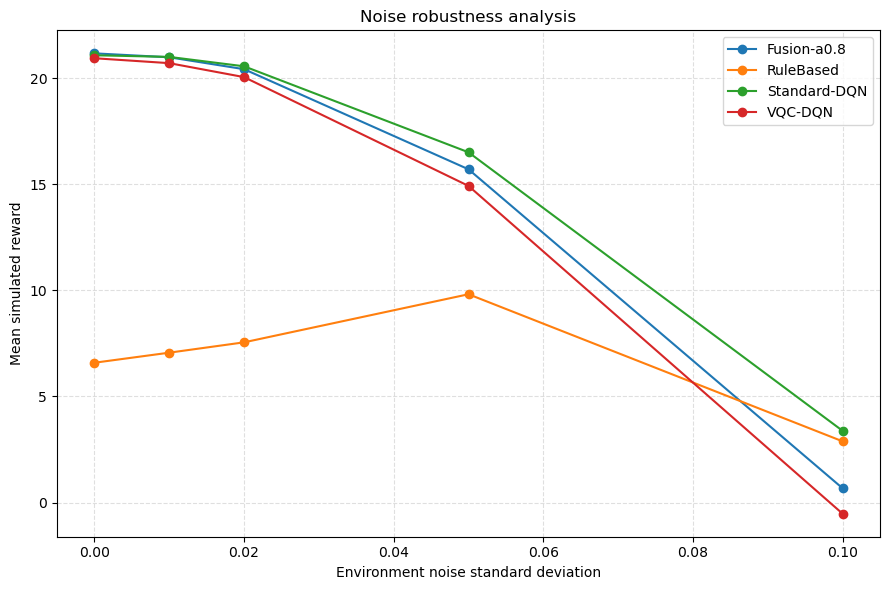

Saved: sepsis_asc_results\asc_final_30seed\figures\FINAL_fig_noise_robustness_reward.png


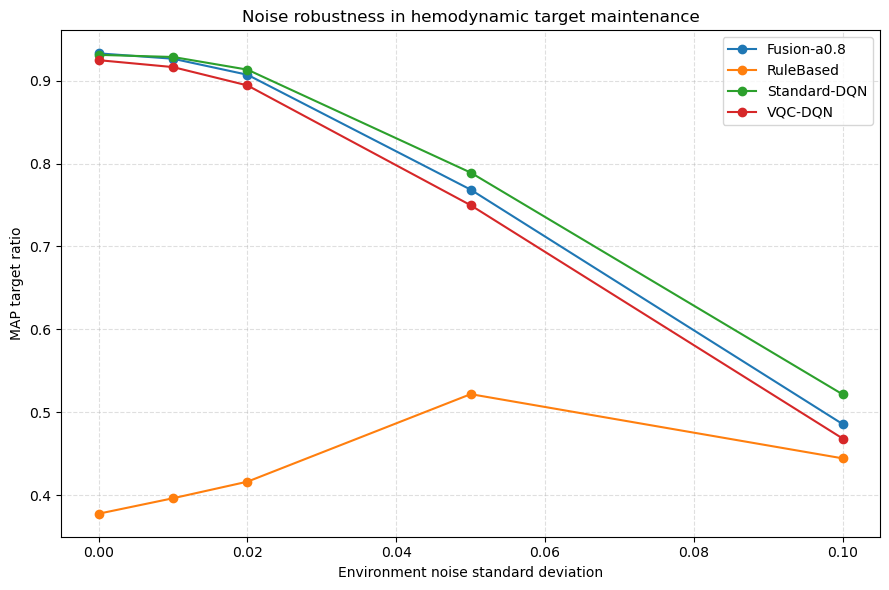

Saved: sepsis_asc_results\asc_final_30seed\figures\FINAL_fig_noise_robustness_map_target.png


In [40]:
# ============================================================
# FINAL NOISE SUMMARY + FIGURES
# ============================================================

noise_summary_final = (
    noise_df_final
    .groupby(["noise_std", "model"])
    .agg(
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        map_target_ratio=("map_target_ratio", "mean"),
        hypotension_rate=("hypotension_rate", "mean"),
        lactate_high_rate=("lactate_high_rate", "mean"),
        action_switch_rate=("action_switch_rate", "mean"),
        terminal_bad_rate=("terminal_bad", "mean"),
    )
    .reset_index()
    .sort_values(["noise_std", "reward_mean"], ascending=[True, False])
)

noise_summary_path = os.path.join(FINAL_RESULT_DIR, "FINAL_noise_robustness_summary.csv")
noise_summary_final.to_csv(noise_summary_path, index=False)

display(noise_summary_final)
print("Saved:", noise_summary_path)

plt.figure(figsize=(9, 6))

for model_name, sub in noise_summary_final.groupby("model"):
    sub = sub.sort_values("noise_std")
    plt.plot(sub["noise_std"], sub["reward_mean"], marker="o", label=model_name)

plt.xlabel("Environment noise standard deviation")
plt.ylabel("Mean simulated reward")
plt.title("Noise robustness analysis")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(FINAL_FIG_DIR, "FINAL_fig_noise_robustness_reward.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)


plt.figure(figsize=(9, 6))

for model_name, sub in noise_summary_final.groupby("model"):
    sub = sub.sort_values("noise_std")
    plt.plot(sub["noise_std"], sub["map_target_ratio"], marker="o", label=model_name)

plt.xlabel("Environment noise standard deviation")
plt.ylabel("MAP target ratio")
plt.title("Noise robustness in hemodynamic target maintenance")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(FINAL_FIG_DIR, "FINAL_fig_noise_robustness_map_target.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

In [41]:
# ============================================================
# REWARD ABLATION CONFIG
# ============================================================

ABLATION_SEEDS = FINAL_SEEDS      
ABLATION_EPISODES = FINAL_EPISODES
ABLATION_EVAL_EPISODES_PER_PROFILE = FINAL_EVAL_EPISODES_PER_PROFILE

REWARD_MODES = [
    "full",
    "map_only",
    "no_lactate",
    "no_switching",
    "no_terminal",
]

ABLATION_DIR = os.path.join(FINAL_RESULT_DIR, "reward_ablation")
os.makedirs(ABLATION_DIR, exist_ok=True)

print("Ablation seeds:", ABLATION_SEEDS)
print("Reward modes:", REWARD_MODES)

Ablation seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Reward modes: ['full', 'map_only', 'no_lactate', 'no_switching', 'no_terminal']


In [ ]:
# ============================================================
# REWARD ABLATION TRAINING + EVALUATION
# ============================================================

ablation_rows = []
ablation_histories = []

for reward_mode in REWARD_MODES:
    print("\n" + "#" * 90)
    print("REWARD ABLATION:", reward_mode)
    print("#" * 90)

    train_env_kwargs = FINAL_ENV_KWARGS.copy()
    train_env_kwargs["reward_mode"] = reward_mode

    full_eval_env_kwargs = FINAL_ENV_KWARGS.copy()
    full_eval_env_kwargs["reward_mode"] = "full"

    for seed in ABLATION_SEEDS:
        print(f"\nReward mode={reward_mode} | seed={seed}")

        seed_ablation_path = os.path.join(ABLATION_DIR, f"ablation_{reward_mode}_seed{seed}.csv")
        if os.path.exists(seed_ablation_path):
            print("Loading existing ablation result:", seed_ablation_path)
            ablation_rows.append(pd.read_csv(seed_ablation_path))
            continue

        # Standard-DQN
        dqn_agent_ab, dqn_hist_ab = train_agent(
            f"Standard-DQN-trained-{reward_mode}",
            lambda: ClassicalQNet(hidden_sizes=(64, 64)),
            seed,
            train_env_kwargs,
            episodes=ABLATION_EPISODES,
        )
        dqn_hist_ab["trained_reward_mode"] = reward_mode
        dqn_hist_ab["base_model"] = "Standard-DQN"
        ablation_histories.append(dqn_hist_ab)

        dqn_eval_ab = evaluate_policy(
            "Standard-DQN",
            agent_policy_fn(dqn_agent_ab),
            seed,
            full_eval_env_kwargs,
            eval_episodes_per_profile=ABLATION_EVAL_EPISODES_PER_PROFILE,
        )
        dqn_eval_ab["trained_reward_mode"] = reward_mode

        # VQC-DQN
        vqc_agent_ab, vqc_hist_ab = train_agent(
            f"VQC-DQN-trained-{reward_mode}",
            lambda: VQCQNet(n_qubits=4, n_layers=3),
            seed,
            train_env_kwargs,
            episodes=ABLATION_EPISODES,
        )
        vqc_hist_ab["trained_reward_mode"] = reward_mode
        vqc_hist_ab["base_model"] = "VQC-DQN"
        ablation_histories.append(vqc_hist_ab)

        vqc_eval_ab = evaluate_policy(
            "VQC-DQN",
            agent_policy_fn(vqc_agent_ab),
            seed,
            full_eval_env_kwargs,
            eval_episodes_per_profile=ABLATION_EVAL_EPISODES_PER_PROFILE,
        )
        vqc_eval_ab["trained_reward_mode"] = reward_mode

        # Fusion
        fusion_eval_ab = evaluate_policy(
            f"Fusion-a{FINAL_MAIN_ALPHA:.1f}",
            fusion_policy_fn(vqc_agent_ab, dqn_agent_ab, alpha=FINAL_MAIN_ALPHA),
            seed,
            full_eval_env_kwargs,
            eval_episodes_per_profile=ABLATION_EVAL_EPISODES_PER_PROFILE,
        )
        fusion_eval_ab["trained_reward_mode"] = reward_mode

        seed_ablation_df = pd.concat(
            [dqn_eval_ab, vqc_eval_ab, fusion_eval_ab],
            ignore_index=True
        )
        seed_ablation_df.to_csv(seed_ablation_path, index=False)

        ablation_rows.append(seed_ablation_df)

ablation_df_final = pd.concat(ablation_rows, ignore_index=True)

ablation_final_path = os.path.join(FINAL_RESULT_DIR, "FINAL_reward_ablation_episode_metrics.csv")
ablation_df_final.to_csv(ablation_final_path, index=False)

display(ablation_df_final.head())
print("Saved:", ablation_final_path)


##########################################################################################
REWARD ABLATION: full
##########################################################################################

Reward mode=full | seed=1
Standard-DQN-trained-full | seed=1 | ep=000/400 | reward=-25.10 | eps=0.990
Standard-DQN-trained-full | seed=1 | ep=020/400 | reward=-18.45 | eps=0.810
Standard-DQN-trained-full | seed=1 | ep=040/400 | reward=-14.90 | eps=0.662
Standard-DQN-trained-full | seed=1 | ep=060/400 | reward=17.85 | eps=0.542
Standard-DQN-trained-full | seed=1 | ep=080/400 | reward=-4.10 | eps=0.443
Standard-DQN-trained-full | seed=1 | ep=100/400 | reward=18.90 | eps=0.362
Standard-DQN-trained-full | seed=1 | ep=120/400 | reward=20.15 | eps=0.296
Standard-DQN-trained-full | seed=1 | ep=140/400 | reward=15.80 | eps=0.242
Standard-DQN-trained-full | seed=1 | ep=160/400 | reward=18.85 | eps=0.198
Standard-DQN-trained-full | seed=1 | ep=180/400 | reward=19.10 | eps=0.162
Standard-DQN-tr